In [ ]:
# 1. Imports, paths, and settings
import warnings
import math
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cycler import cycler
from scipy.optimize import minimize
from scipy.stats import norm
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from IPython.display import display
from arch import arch_model

from quantfinlab.options.diagnostics import build_atm_iv_panel_from_option_quotes

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

palette = [
    "#006d77", "#e29578", "#264653", "#2a9d8f", "#e9c46a",
    "#f4a261", "#d62828", "#457b9d", "#7b2cbf", "#6a994e",
]
plt.rcParams["axes.prop_cycle"] = cycler(color=palette)
plt.rcParams.update({
    "figure.figsize": (7, 3.2),
    "figure.dpi": 160,
    "savefig.dpi": 250,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
})

seed = 7
np.random.seed(seed)

cwd = Path.cwd().resolve()
project_root = cwd if (cwd / "data").exists() else cwd.parent
data_dir = project_root / "data"

option_path = data_dir / "spx_options_chain_202201_202312.parquet"
rate_path = data_dir / "par-yield-curve-rates-1990-2026.csv"
spy_path = data_dir / "spy_yfinance.csv"
spx_path = data_dir / "spx_daily_yfinance.csv"

HORIZONS = (1, 5, 10, 21, 42, 63)
ANNUALIZATION = 252
CALENDAR_DAYS = 365.25
EPS = 1e-12


In [ ]:
# 2. Load SPX, SPY, rates, and SPX options
required_files = [option_path, rate_path, spy_path, spx_path]
missing = [str(p) for p in required_files if not p.exists()]
if missing:
    raise FileNotFoundError("Missing required Project 5 data files: " + ", ".join(missing))

chain_cols = [
    "quote_date", "quote_readtime", "expire_date", "underlying_last",
    "strike", "c_bid", "c_ask", "p_bid", "p_ask", "c_volume", "p_volume",
]
df_chain = pd.read_parquet(option_path, columns=chain_cols)
df_rates = pd.read_csv(rate_path)
df_spy_raw = pd.read_csv(spy_path)
df_spx_raw = pd.read_csv(spx_path)

for col in ["quote_date", "quote_readtime", "expire_date"]:
    df_chain[col] = pd.to_datetime(df_chain[col], errors="coerce")
df_chain["trade_date"] = df_chain["quote_date"].dt.normalize()
df_chain["expiry_datetime"] = df_chain["expire_date"].dt.normalize()
df_chain["quote_datetime"] = pd.to_datetime(df_chain["quote_readtime"], errors="coerce")
df_chain["dte_calendar"] = (df_chain["expiry_datetime"] - df_chain["trade_date"]).dt.total_seconds() / 86400.0
for col in ["underlying_last", "strike", "c_bid", "c_ask", "p_bid", "p_ask", "c_volume", "p_volume"]:
    df_chain[col] = pd.to_numeric(df_chain[col], errors="coerce")

def clean_yfinance_price_frame(raw, price_name, include_dividend=False):
    data = raw.copy()
    data.columns = [str(c).strip().lower().replace(" ", "_") for c in data.columns]
    if "date" not in data.columns:
        raise ValueError(f"{price_name} file must contain a date column")
    data["trade_date"] = pd.to_datetime(data["date"], errors="coerce").dt.normalize()
    price_col = "adj_close" if "adj_close" in data.columns else "close"
    data[price_col] = pd.to_numeric(data[price_col], errors="coerce")
    out = data[["trade_date", price_col]].rename(columns={price_col: price_name})
    if include_dividend:
        div_col = "dividends" if "dividends" in data.columns else None
        out["dividend"] = pd.to_numeric(data[div_col], errors="coerce").fillna(0.0) if div_col else 0.0
    return out.dropna(subset=["trade_date", price_name]).sort_values("trade_date").drop_duplicates("trade_date", keep="last")

df_spx = clean_yfinance_price_frame(df_spx_raw, "spx_close")
df_spy = clean_yfinance_price_frame(df_spy_raw, "spy_close", include_dividend=True)

df_spx["spx_ret"] = np.log(df_spx["spx_close"] / df_spx["spx_close"].shift(1))
spy_prev = df_spy["spy_close"].shift(1)
df_spy["spy_ret_tr"] = np.log(np.clip((df_spy["spy_close"] + df_spy["dividend"]) / spy_prev, EPS, None))

df_market = (
    df_spx.merge(df_spy[["trade_date", "spy_close", "spy_ret_tr", "dividend"]], on="trade_date", how="inner")
    .sort_values("trade_date")
    .reset_index(drop=True)
)

beta_window = 60
roll_cov = df_market["spx_ret"].rolling(beta_window).cov(df_market["spy_ret_tr"])
roll_var = df_market["spy_ret_tr"].rolling(beta_window).var()
df_market["beta_spx_to_spy"] = (roll_cov / roll_var).replace([np.inf, -np.inf], np.nan).clip(0.85, 1.15)
df_market["beta_spx_to_spy"] = df_market["beta_spx_to_spy"].bfill().ffill().fillna(1.0)

ret = df_market["spx_ret"].to_numpy(dtype=float)
for h in HORIZONS:
    rv_sum = np.full(len(df_market), np.nan, dtype=float)
    for i in range(len(df_market) - h):
        window = ret[i + 1 : i + 1 + h]
        if np.isfinite(window).all():
            rv_sum[i] = float(np.sum(window * window))
    df_market[f"realized_var_sum_fwd_{h}"] = rv_sum
    df_market[f"realized_var_ann_fwd_{h}"] = ANNUALIZATION / h * rv_sum
    df_market[f"realized_vol_ann_fwd_{h}"] = np.sqrt(np.clip(df_market[f"realized_var_ann_fwd_{h}"], 0, None))

display(pd.DataFrame({
    "metric": ["raw_option_rows", "option_dates", "option_expiries", "market_dates", "return_start", "return_end"],
    "value": [
        int(len(df_chain)),
        int(df_chain["trade_date"].nunique()),
        int(df_chain["expiry_datetime"].nunique()),
        int(len(df_market)),
        str(df_market["trade_date"].min().date()),
        str(df_market["trade_date"].max().date()),
    ],
}))
display(df_market.head())


In [ ]:
# 3. Realized-volatility targets and market overview
rv_windows = [10, 21, 42, 63, 84, 126]
for w in rv_windows:
    df_market[f"rv_trailing_{w}"] = df_market["spx_ret"].rolling(w).std() * np.sqrt(ANNUALIZATION)

fig, axes = plt.subplots(2, 1, figsize=(10.5, 7.0), sharex=True)
axes[0].plot(df_market["trade_date"], df_market["spx_close"], lw=1.2, label="SPX")
axes[0].plot(df_market["trade_date"], df_market["spy_close"] * 10.0, lw=0.9, alpha=0.8, label="SPY x 10")
axes[0].set_title("SPX and scaled SPY")
axes[0].legend(loc="best")

axes[1].plot(df_market["trade_date"], df_market["rv_trailing_21"], lw=1.0, label="trailing 21d realized vol")
axes[1].plot(df_market["trade_date"], df_market["realized_vol_ann_fwd_21"], lw=0.9, alpha=0.75, label="future 21d realized vol")
axes[1].plot(df_market["trade_date"], df_market["rv_trailing_63"], lw=1.0, alpha=0.85, label="trailing 63d realized vol")
axes[1].set_title("Realized-volatility regimes")
axes[1].legend(loc="best")
plt.tight_layout()
plt.show()


In [ ]:
# 4. Project 4 library handoff: clean ATM IV panel
# This is the only SPX block that delegates the Project 4 options workflow:
# wide quote normalization, quote cleaning, rate attachment, parity forwards,
# BSM implied-volatility solving, and ATM option-pair selection.
t0 = time.time()
iv_panel_all = build_atm_iv_panel_from_option_quotes(
    df_chain,
    rates=df_rates,
    min_dte=7,
    max_dte=120,
    moneyness_range=(0.85, 1.15),
    max_relative_spread=0.20,
    closest_atm_pairs=25,
    min_pairs_per_expiry=10,
    solver="lbr_lite",
    engine="auto",
    underlying_default="SPX",
)
print(f"ATM IV panel build time: {time.time() - t0:,.1f}s")
print("IV solver engine:", iv_panel_all.attrs.get("iv_engine", "unknown"))

iv_cleaning_report = iv_panel_all.attrs.get("cleaning_report", pd.DataFrame())
display(iv_cleaning_report)
if iv_panel_all.empty:
    raise RuntimeError("The Project 4 IV wrapper returned an empty ATM IV panel.")

iv_panel_all["date"] = pd.to_datetime(iv_panel_all["date"], errors="coerce").dt.normalize()
iv_panel_all["expiry"] = pd.to_datetime(iv_panel_all["expiry"], errors="coerce").dt.normalize()
iv_panel_all["dte_calendar"] = pd.to_numeric(iv_panel_all["dte_calendar"], errors="coerce")
iv_panel_all["dte_trading"] = pd.to_numeric(iv_panel_all["dte_trading"], errors="coerce")
iv_panel_all["atm_iv_mid"] = pd.to_numeric(iv_panel_all["atm_iv_mid"], errors="coerce")
if iv_panel_all["atm_iv_mid"].dropna().median() > 2.0:
    for col in ["atm_iv_bid", "atm_iv_mid", "atm_iv_ask"]:
        if col in iv_panel_all:
            iv_panel_all[col] = iv_panel_all[col] / 100.0

iv_30d_daily = (
    iv_panel_all[(iv_panel_all["dte_calendar"] >= 21) & (iv_panel_all["dte_calendar"] <= 45)]
    .assign(dte_score=lambda x: (x["dte_calendar"] - 30.0).abs())
    .sort_values(["date", "dte_score", "quote_quality_score"])
    .groupby("date", as_index=False)
    .head(1)
    .drop(columns=["dte_score"], errors="ignore")
    .reset_index(drop=True)
)

display(pd.DataFrame({
    "metric": ["all_atm_rows", "daily_30d_rows", "first_date", "last_date", "median_atm_iv", "median_dte_calendar"],
    "value": [
        int(len(iv_panel_all)),
        int(len(iv_30d_daily)),
        str(iv_30d_daily["date"].min().date()),
        str(iv_30d_daily["date"].max().date()),
        float(iv_30d_daily["atm_iv_mid"].median()),
        float(iv_30d_daily["dte_calendar"].median()),
    ],
}))
display(iv_30d_daily.head())


In [ ]:
# 5. Manual GARCH(1,1) implementation
returns_series = df_market.loc[df_market["spx_ret"].notna(), ["trade_date", "spx_ret"]].copy().reset_index(drop=True)
ret_pct = 100.0 * returns_series["spx_ret"].to_numpy(dtype=float)

def garch_backcast(resids, decay=0.94, horizon=75):
    x = np.asarray(resids, dtype=float) ** 2
    n = min(len(x), horizon)
    if n == 0:
        return 1.0
    w = decay ** np.arange(n)
    w = w / w.sum()
    return float(np.sum(w * x[:n][::-1]))

def garch11_filter_backcast(returns_pct, omega, alpha, beta, backcast=None):
    eps = np.asarray(returns_pct, dtype=float)
    n = len(eps)
    sigma2 = np.empty(n, dtype=float)
    if backcast is None:
        backcast = garch_backcast(eps)
    sigma2[0] = max(float(backcast), 1e-8)
    for t in range(1, n):
        sigma2[t] = omega + alpha * eps[t - 1] ** 2 + beta * sigma2[t - 1]
        sigma2[t] = max(sigma2[t], 1e-10)
    return sigma2

def garch11_negloglik_normal(params, returns_pct, backcast=None):
    omega, alpha, beta = [float(x) for x in params]
    if omega <= 0.0 or alpha < 0.0 or beta < 0.0 or alpha + beta >= 0.999:
        return 1e16
    sigma2 = garch11_filter_backcast(returns_pct, omega, alpha, beta, backcast=backcast)
    ll = -0.5 * (np.log(2.0 * np.pi) + np.log(sigma2) + (returns_pct ** 2) / sigma2)
    value = -float(np.sum(ll))
    return value if np.isfinite(value) else 1e16

def garch11_multi_horizon_variance(last_sigma2, last_eps, omega, alpha, beta, horizons):
    horizons = sorted(set(int(h) for h in horizons))
    out = {}
    h1 = omega + alpha * float(last_eps) ** 2 + beta * float(last_sigma2)
    out[1] = h1
    prev = h1
    for h in range(2, max(horizons) + 1):
        prev = omega + (alpha + beta) * prev
        out[h] = prev
    return {h: out[h] for h in horizons}

def fit_manual_garch11_normal(returns_pct):
    y = np.asarray(returns_pct, dtype=float)
    y = y[np.isfinite(y)]
    backcast = garch_backcast(y)
    var0 = max(float(np.var(y, ddof=1)), 1e-6)
    starts = []
    for alpha0, beta0 in [(0.05, 0.90), (0.08, 0.90), (0.10, 0.85), (0.03, 0.95), (0.12, 0.80)]:
        if alpha0 + beta0 < 0.999:
            starts.append(np.array([max((1.0 - alpha0 - beta0) * var0, 1e-8), alpha0, beta0], dtype=float))
    bounds = [(1e-12, 100.0 * var0), (1e-8, 0.999), (1e-8, 0.999)]
    cons = [{"type": "ineq", "fun": lambda x: 0.999 - x[1] - x[2]}]
    best = None
    for x0 in starts:
        try:
            res = minimize(
                garch11_negloglik_normal,
                x0=x0,
                args=(y, backcast),
                method="SLSQP",
                bounds=bounds,
                constraints=cons,
                options={"maxiter": 2000, "ftol": 1e-12},
            )
            if best is None or res.fun < best.fun:
                best = res
        except Exception:
            pass
    if best is None:
        raise RuntimeError("manual GARCH fit failed")
    omega, alpha, beta = [float(v) for v in best.x]
    sigma2 = garch11_filter_backcast(y, omega, alpha, beta, backcast=backcast)
    std_resid = y / np.sqrt(np.clip(sigma2, 1e-12, None))
    ll = -garch11_negloglik_normal([omega, alpha, beta], y, backcast)
    n = len(y)
    k = 3
    return {
        "success": bool(best.success),
        "message": str(best.message),
        "omega": omega,
        "alpha": alpha,
        "beta": beta,
        "persistence": alpha + beta,
        "backcast": backcast,
        "sigma2": sigma2,
        "std_resid": std_resid,
        "loglik": ll,
        "aic": 2.0 * k - 2.0 * ll,
        "bic": math.log(n) * k - 2.0 * ll,
        "unc_var": omega / max(1.0 - alpha - beta, 1e-8),
    }

manual_fit = fit_manual_garch11_normal(ret_pct)
am_manual_check = arch_model(ret_pct, mean="Zero", vol="GARCH", p=1, q=1, dist="normal", rescale=False)
res_manual_check = am_manual_check.fit(disp="off", show_warning=False)

display(pd.DataFrame([
    {
        "model": "manual_garch11_normal",
        "success": manual_fit["success"],
        "omega": manual_fit["omega"],
        "alpha": manual_fit["alpha"],
        "beta": manual_fit["beta"],
        "persistence": manual_fit["persistence"],
        "unc_var_pct2": manual_fit["unc_var"],
        "aic": manual_fit["aic"],
        "bic": manual_fit["bic"],
    },
    {
        "model": "arch_garch11_normal",
        "success": True,
        "omega": float(res_manual_check.params.get("omega", np.nan)),
        "alpha": float(res_manual_check.params.get("alpha[1]", np.nan)),
        "beta": float(res_manual_check.params.get("beta[1]", np.nan)),
        "persistence": float(res_manual_check.params.get("alpha[1]", np.nan) + res_manual_check.params.get("beta[1]", np.nan)),
        "unc_var_pct2": float(res_manual_check.params.get("omega", np.nan) / max(1.0 - res_manual_check.params.get("alpha[1]", np.nan) - res_manual_check.params.get("beta[1]", np.nan), 1e-8)),
        "aic": float(res_manual_check.aic),
        "bic": float(res_manual_check.bic),
    },
]))


In [ ]:
# 6. Manual vs arch validation
manual_dates = returns_series["trade_date"].reset_index(drop=True)
arch_cond_vol = np.asarray(res_manual_check.conditional_volatility, dtype=float)

fig, axes = plt.subplots(2, 2, figsize=(13.0, 8.2))
axes[0, 0].plot(manual_dates, np.sqrt(ANNUALIZATION) * np.sqrt(manual_fit["sigma2"]) / 100.0, lw=1.2, label="manual normal")
axes[0, 0].plot(manual_dates, np.sqrt(ANNUALIZATION) * arch_cond_vol / 100.0, lw=1.0, label="arch normal")
axes[0, 0].plot(df_market["trade_date"], df_market["realized_vol_ann_fwd_21"], lw=0.9, alpha=0.8, label="future RV 21d")
axes[0, 0].set_title("Manual vs arch GARCH(1,1) conditional volatility")
axes[0, 0].legend(loc="best")

axes[0, 1].hist(manual_fit["std_resid"], bins=60, alpha=0.70, density=True, label="manual std resid")
x = np.linspace(-4.5, 4.5, 300)
axes[0, 1].plot(x, norm.pdf(x), lw=1.4, c="black", label="standard normal")
axes[0, 1].set_title("Manual standardized residuals")
axes[0, 1].legend(loc="best")

q_grid = np.linspace(0.01, 0.99, 200)
norm_q = norm.ppf(q_grid)
std_resid_manual = np.sort(pd.Series(manual_fit["std_resid"]).replace([np.inf, -np.inf], np.nan).dropna().to_numpy(dtype=float))
idx = np.linspace(0, len(std_resid_manual) - 1, len(norm_q)).astype(int)
axes[1, 0].scatter(norm_q, std_resid_manual[idx], s=10, alpha=0.55)
lo = min(norm_q.min(), std_resid_manual[idx].min())
hi = max(norm_q.max(), std_resid_manual[idx].max())
axes[1, 0].plot([lo, hi], [lo, hi], ls="--", lw=1.0, c="black")
axes[1, 0].set_title("Manual GARCH QQ plot")

sigma_diff = np.sqrt(manual_fit["sigma2"]) - arch_cond_vol
axes[1, 1].plot(manual_dates, sigma_diff, lw=1.1)
axes[1, 1].axhline(0.0, lw=1.0, ls="--", c="black")
axes[1, 1].set_title("Manual minus arch conditional sigma (pct units)")
plt.tight_layout()
plt.show()

display(pd.DataFrame([
    {"metric": "manual_arch_param_abs_diff_omega", "value": abs(manual_fit["omega"] - float(res_manual_check.params.get("omega", np.nan)))},
    {"metric": "manual_arch_param_abs_diff_alpha", "value": abs(manual_fit["alpha"] - float(res_manual_check.params.get("alpha[1]", np.nan)))},
    {"metric": "manual_arch_param_abs_diff_beta", "value": abs(manual_fit["beta"] - float(res_manual_check.params.get("beta[1]", np.nan)))},
    {"metric": "manual_arch_sigma_corr", "value": float(np.corrcoef(np.sqrt(manual_fit["sigma2"]), arch_cond_vol)[0, 1])},
]))


In [ ]:
# 7. GARCH-family model zoo
def fit_arch_model_visible(returns_pct, vol, p, q, dist, o=0, maxiter=600):
    model = arch_model(
        returns_pct,
        mean="Zero",
        vol=vol,
        p=p,
        o=o,
        q=q,
        dist=dist,
        rescale=False,
    )
    res = model.fit(disp="off", show_warning=False, options={"maxiter": int(maxiter)})
    return model, res

model_specs = [
    {"name": "garch11_normal", "vol": "GARCH", "p": 1, "o": 0, "q": 1, "dist": "normal"},
    {"name": "garch11_student", "vol": "GARCH", "p": 1, "o": 0, "q": 1, "dist": "t"},
    {"name": "garch22_normal", "vol": "GARCH", "p": 2, "o": 0, "q": 2, "dist": "normal"},
    {"name": "garch22_student", "vol": "GARCH", "p": 2, "o": 0, "q": 2, "dist": "t"},
    {"name": "gjr11_normal", "vol": "GARCH", "p": 1, "o": 1, "q": 1, "dist": "normal"},
    {"name": "gjr11_student", "vol": "GARCH", "p": 1, "o": 1, "q": 1, "dist": "t"},
    {"name": "egarch11_normal", "vol": "EGARCH", "p": 1, "o": 0, "q": 1, "dist": "normal"},
    {"name": "egarch11_student", "vol": "EGARCH", "p": 1, "o": 0, "q": 1, "dist": "t"},
]

full_sample_fits = {}
fit_rows = []
for spec in model_specs:
    try:
        model, res = fit_arch_model_visible(
            returns_pct=ret_pct,
            vol=spec["vol"],
            p=spec["p"],
            o=spec["o"],
            q=spec["q"],
            dist=spec["dist"],
        )
        full_sample_fits[spec["name"]] = {"model": model, "res": res, "spec": spec}
        params = res.params.to_dict()
        fit_rows.append({
            "model": spec["name"],
            "loglik": float(res.loglikelihood),
            "aic": float(res.aic),
            "bic": float(res.bic),
            "omega": float(params.get("omega", np.nan)),
            "alpha1": float(params.get("alpha[1]", np.nan)),
            "alpha2": float(params.get("alpha[2]", np.nan)),
            "gamma1": float(params.get("gamma[1]", np.nan)),
            "beta1": float(params.get("beta[1]", np.nan)),
            "beta2": float(params.get("beta[2]", np.nan)),
            "nu": float(params.get("nu", np.nan)),
        })
    except Exception as exc:
        fit_rows.append({"model": spec["name"], "loglik": np.nan, "aic": np.nan, "bic": np.nan, "error": str(exc)})

df_full_sample_fit = pd.DataFrame(fit_rows).sort_values(["aic", "bic"]).reset_index(drop=True)
display(df_full_sample_fit)

selected_models_for_plot = [m for m in ["garch11_student", "garch22_student", "gjr11_student", "egarch11_student"] if m in full_sample_fits]
fig, axes = plt.subplots(2, 2, figsize=(13.2, 8.8), sharex=False)
axes = axes.ravel()
for ax, name in zip(axes, selected_models_for_plot):
    res = full_sample_fits[name]["res"]
    cond_vol = np.asarray(res.conditional_volatility, dtype=float) / 100.0 * np.sqrt(ANNUALIZATION)
    ax.plot(returns_series["trade_date"], cond_vol, lw=1.0, label=name)
    ax.plot(df_market["trade_date"], df_market["realized_vol_ann_fwd_21"], lw=0.8, alpha=0.75, label="future RV 21d")
    ax.set_title(name)
    ax.legend(loc="best")
for ax in axes[len(selected_models_for_plot):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

diag_rows = []
for name, entry in full_sample_fits.items():
    res = entry["res"]
    std_resid = pd.Series(res.std_resid).replace([np.inf, -np.inf], np.nan).dropna()
    if len(std_resid) < 40:
        continue
    lb_r = acorr_ljungbox(std_resid, lags=[10, 20], return_df=True)
    lb_s = acorr_ljungbox(std_resid ** 2, lags=[10, 20], return_df=True)
    arch_lm = het_arch(std_resid, nlags=10)
    params = res.params
    persistence = float(np.nansum([params.get(k, np.nan) for k in params.index if (k.startswith("alpha[") or k.startswith("beta[") or k.startswith("gamma["))]))
    alpha1 = float(params.get("alpha[1]", np.nan))
    beta1 = float(params.get("beta[1]", np.nan))
    half_life = math.log(0.5) / math.log(alpha1 + beta1) if np.isfinite(alpha1 + beta1) and 0 < alpha1 + beta1 < 1 else np.nan
    diag_rows.append({
        "model": name,
        "lb_resid_p_10": float(lb_r["lb_pvalue"].iloc[0]),
        "lb_resid_p_20": float(lb_r["lb_pvalue"].iloc[-1]),
        "lb_sq_p_10": float(lb_s["lb_pvalue"].iloc[0]),
        "lb_sq_p_20": float(lb_s["lb_pvalue"].iloc[-1]),
        "arch_lm_stat_10": float(arch_lm[0]),
        "arch_lm_p_10": float(arch_lm[1]),
        "persistence_like_sum": persistence,
        "half_life_days_garch11_style": half_life,
    })
df_ts_diagnostics = pd.DataFrame(diag_rows).sort_values("lb_sq_p_20", ascending=False).reset_index(drop=True)
display(df_ts_diagnostics)


In [ ]:
# 8. HAR-RV implementation
def make_har_features_visible(rv_daily, weekly_window=5, monthly_window=22, use_log=True, eps=EPS):
    rv = pd.Series(rv_daily).copy()
    rv.index = pd.to_datetime(rv.index, errors="coerce")
    rv = pd.to_numeric(rv, errors="coerce").replace([np.inf, -np.inf], np.nan).sort_index()
    features = pd.DataFrame(index=rv.index)
    features["rv_daily"] = rv
    features["rv_weekly"] = rv.rolling(weekly_window, min_periods=weekly_window).mean()
    features["rv_monthly"] = rv.rolling(monthly_window, min_periods=monthly_window).mean()
    if use_log:
        features = np.log(features.clip(lower=eps))
        features = features.rename(columns=lambda c: "log_" + c)
    return features

def forward_realized_var_sum(returns, horizon):
    r = pd.Series(returns).copy()
    vals = pd.to_numeric(r, errors="coerce").to_numpy(dtype=float)
    out = np.full(len(vals), np.nan, dtype=float)
    h = int(horizon)
    for i in range(len(vals) - h):
        window = vals[i + 1 : i + 1 + h]
        if np.isfinite(window).all():
            out[i] = float(np.sum(window * window))
    return pd.Series(out, index=r.index, name=f"realized_var_sum_{h}")

def fit_har_ols_visible(features, target_sum, use_log=True, eps=EPS):
    data = features.join(target_sum.rename("target"), how="inner").replace([np.inf, -np.inf], np.nan).dropna()
    if len(data) < features.shape[1] + 20:
        raise ValueError("not enough HAR-RV observations")
    y = pd.to_numeric(data["target"], errors="coerce")
    if use_log:
        y = np.log(y.clip(lower=eps))
    X = np.column_stack([np.ones(len(data)), data[features.columns].to_numpy(dtype=float)])
    beta, *_ = np.linalg.lstsq(X, np.asarray(y, dtype=float), rcond=None)
    return pd.Series(beta, index=["const", *features.columns])

def predict_har_sum_visible(params, feature_row, use_log=True, eps=EPS):
    x = np.r_[1.0, feature_row.to_numpy(dtype=float)]
    pred = float(np.dot(params.to_numpy(dtype=float), x))
    if use_log:
        pred = float(np.exp(pred))
    return max(pred, eps)

def rolling_har_forecasts_visible(returns_df, signal_dates, horizons=HORIZONS, train_window=756, annualization=ANNUALIZATION, use_log=True, eps=EPS):
    ser = returns_df.set_index("trade_date")["spx_ret"].dropna().sort_index()
    rv_daily = ser * ser
    features = make_har_features_visible(rv_daily, use_log=use_log, eps=eps)
    targets = {int(h): forward_realized_var_sum(ser, int(h)) for h in horizons}
    dates = pd.DatetimeIndex(ser.index)
    date_to_pos = {pd.Timestamp(d).normalize(): i for i, d in enumerate(dates)}
    records = []
    for signal_date in pd.DatetimeIndex(pd.to_datetime(signal_dates)).normalize().unique().sort_values():
        pos = date_to_pos.get(pd.Timestamp(signal_date).normalize())
        if pos is None or pos < train_window or pos + max(horizons) >= len(ser):
            continue
        if signal_date not in features.index or features.loc[[signal_date]].isna().any(axis=None):
            continue
        for h in horizons:
            h = int(h)
            known_end_pos = pos - h
            if known_end_pos <= 0:
                continue
            train_start = max(0, known_end_pos - int(train_window) + 1)
            train_dates = dates[train_start : known_end_pos + 1]
            try:
                params = fit_har_ols_visible(features.loc[train_dates], targets[h].loc[train_dates], use_log=use_log, eps=eps)
                forecast_sum = predict_har_sum_visible(params, features.loc[signal_date], use_log=use_log, eps=eps)
            except Exception:
                continue
            realized_sum = float(targets[h].loc[signal_date])
            forecast_ann = annualization / h * forecast_sum
            realized_ann = annualization / h * realized_sum if np.isfinite(realized_sum) else np.nan
            records.append({
                "date": signal_date,
                "model": "har_rv",
                "horizon": h,
                "forecast_var_sum": forecast_sum,
                "forecast_var_ann": forecast_ann,
                "forecast_vol_ann": float(np.sqrt(max(forecast_ann, 0.0))),
                "realized_var_sum": realized_sum,
                "realized_var_ann": realized_ann,
                "realized_vol_ann": float(np.sqrt(max(realized_ann, 0.0))) if np.isfinite(realized_ann) else np.nan,
                "n_train": int(len(train_dates)),
            })
    return pd.DataFrame(records).sort_values(["date", "horizon"]).reset_index(drop=True)

har_feature_preview = make_har_features_visible(df_market.set_index("trade_date")["spx_ret"].dropna() ** 2).dropna().head()
display(har_feature_preview)


In [ ]:
# 9. Daily/signal forecast generation
# Each ARCH-family row below is fitted on its own signal date using data available through that date.
# Nothing is forward-filled between model fits, so stale repeated forecasts are not treated as new signals.
FORECAST_TRAIN_WINDOW = 756
FAST_DEMO_MODE = False
signal_dates_all = pd.DatetimeIndex(iv_30d_daily["date"].dropna().unique()).sort_values()
if FAST_DEMO_MODE:
    signal_dates = signal_dates_all[::5]
else:
    signal_dates = signal_dates_all
signal_dates = signal_dates[(signal_dates >= returns_series["trade_date"].min()) & (signal_dates <= returns_series["trade_date"].max())]
display(pd.DataFrame({"metric": ["signal_dates", "first_signal", "last_signal"], "value": [len(signal_dates), signal_dates.min(), signal_dates.max()]}))

def arch_forecast_variance_vector(res, max_horizon, simulations=500, seed=7):
    try:
        fc = res.forecast(horizon=int(max_horizon), reindex=False, method="analytic")
    except Exception:
        np.random.seed(seed)
        fc = res.forecast(horizon=int(max_horizon), reindex=False, method="simulation", simulations=int(simulations))
    return np.asarray(fc.variance.values[-1], dtype=float).reshape(-1)

def rolling_arch_forecasts_daily_refit(returns_df, signal_dates, specs, horizons=HORIZONS, train_window=756, annualization=ANNUALIZATION, maxiter=500):
    data = returns_df.dropna(subset=["trade_date", "spx_ret"]).copy()
    data["trade_date"] = pd.to_datetime(data["trade_date"], errors="coerce").dt.normalize()
    data = data.sort_values("trade_date").reset_index(drop=True)
    dates = pd.DatetimeIndex(data["trade_date"])
    returns = data["spx_ret"].to_numpy(dtype=float)
    ret_pct_all = 100.0 * returns
    date_to_pos = {pd.Timestamp(d).normalize(): i for i, d in enumerate(dates)}
    max_h = int(max(horizons))
    records = []
    error_rows = []
    for signal_idx, signal_date in enumerate(pd.DatetimeIndex(signal_dates).normalize().unique().sort_values()):
        pos = date_to_pos.get(pd.Timestamp(signal_date).normalize())
        if pos is None or pos < train_window or pos + max_h >= len(data):
            continue
        train = ret_pct_all[pos - train_window + 1 : pos + 1]
        if not np.isfinite(train).all():
            train = train[np.isfinite(train)]
        if len(train) < train_window:
            continue
        for spec_idx, spec in enumerate(specs):
            name = spec["name"]
            try:
                _, res = fit_arch_model_visible(
                    train,
                    vol=spec["vol"],
                    p=spec["p"],
                    o=spec.get("o", 0),
                    q=spec["q"],
                    dist=spec["dist"],
                    maxiter=maxiter,
                )
                fc_pct2 = arch_forecast_variance_vector(res, max_h, seed=seed + 1009 * spec_idx + signal_idx)
            except Exception as exc:
                error_rows.append({"date": signal_date, "model": name, "error": str(exc)})
                continue
            for h in horizons:
                h = int(h)
                forecast_sum = float(np.sum(fc_pct2[:h]) / (100.0 ** 2))
                realized_window = returns[pos + 1 : pos + 1 + h]
                realized_sum = float(np.sum(realized_window * realized_window)) if len(realized_window) == h and np.isfinite(realized_window).all() else np.nan
                forecast_ann = annualization / h * forecast_sum
                realized_ann = annualization / h * realized_sum if np.isfinite(realized_sum) else np.nan
                records.append({
                    "date": signal_date,
                    "model": name,
                    "horizon": h,
                    "forecast_var_sum": forecast_sum,
                    "forecast_var_ann": forecast_ann,
                    "forecast_vol_ann": float(np.sqrt(max(forecast_ann, 0.0))),
                    "realized_var_sum": realized_sum,
                    "realized_var_ann": realized_ann,
                    "realized_vol_ann": float(np.sqrt(max(realized_ann, 0.0))) if np.isfinite(realized_ann) else np.nan,
                    "n_train": int(len(train)),
                })
    out = pd.DataFrame(records).sort_values(["date", "model", "horizon"]).reset_index(drop=True)
    errors = pd.DataFrame(error_rows)
    return out, errors

t0 = time.time()
df_garch_fc, df_arch_errors = rolling_arch_forecasts_daily_refit(
    returns_series,
    signal_dates,
    model_specs,
    horizons=HORIZONS,
    train_window=FORECAST_TRAIN_WINDOW,
    maxiter=500,
)
df_har_fc = rolling_har_forecasts_visible(
    returns_series,
    signal_dates,
    horizons=HORIZONS,
    train_window=FORECAST_TRAIN_WINDOW,
)
df_fc_signal = pd.concat([df_garch_fc, df_har_fc], ignore_index=True).sort_values(["date", "model", "horizon"]).reset_index(drop=True)
print(f"Forecast generation time: {time.time() - t0:,.1f}s")
print("Forecast panel rows:", len(df_fc_signal), "models:", sorted(df_fc_signal["model"].dropna().unique()))
if not df_arch_errors.empty:
    display(df_arch_errors.groupby("model").size().rename("fit_errors").reset_index())
display(df_fc_signal.head())


In [ ]:
# 10. Forecast scoring by horizon
def qlike_loss(realized_var, forecast_var, eps=EPS):
    realized_var = np.asarray(realized_var, dtype=float)
    forecast_var = np.asarray(forecast_var, dtype=float)
    mask = np.isfinite(realized_var) & np.isfinite(forecast_var) & (realized_var > 0) & (forecast_var > 0)
    if mask.sum() == 0:
        return np.nan
    rv = np.clip(realized_var[mask], eps, None)
    fv = np.clip(forecast_var[mask], eps, None)
    return float(np.mean(np.log(fv) + rv / fv))

def qlike_array(realized_var, forecast_var, eps=EPS):
    rv = np.asarray(realized_var, dtype=float)
    fv = np.asarray(forecast_var, dtype=float)
    out = np.full(len(rv), np.nan, dtype=float)
    mask = np.isfinite(rv) & np.isfinite(fv) & (rv > 0) & (fv > 0)
    out[mask] = np.log(np.clip(fv[mask], eps, None)) + np.clip(rv[mask], eps, None) / np.clip(fv[mask], eps, None)
    return out

def mz_regression(y, x, maxlags=5):
    z = pd.DataFrame({"y": y, "x": x}).replace([np.inf, -np.inf], np.nan).dropna()
    if len(z) < 25:
        return {"alpha": np.nan, "beta": np.nan, "r2": np.nan, "alpha_p": np.nan, "beta_p": np.nan, "n_obs": int(len(z))}
    X = sm.add_constant(z["x"])
    res = sm.OLS(z["y"], X).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})
    return {
        "alpha": float(res.params.get("const", np.nan)),
        "beta": float(res.params.get("x", np.nan)),
        "r2": float(res.rsquared),
        "alpha_p": float(res.pvalues.get("const", np.nan)),
        "beta_p": float(res.pvalues.get("x", np.nan)),
        "n_obs": int(len(z)),
    }

def dm_test(loss_a, loss_b, h=1):
    d = pd.Series(np.asarray(loss_a, dtype=float) - np.asarray(loss_b, dtype=float)).replace([np.inf, -np.inf], np.nan).dropna().to_numpy()
    n = len(d)
    if n < max(20, int(h) + 5):
        return {"dm_stat": np.nan, "dm_pvalue": np.nan, "n": n}
    mean_d = float(np.mean(d))
    long_run = float(np.var(d, ddof=1))
    max_lag = int(max(1, h - 1))
    for lag in range(1, max_lag + 1):
        cov = np.cov(d[lag:], d[:-lag], ddof=1)[0, 1]
        long_run += 2.0 * (1.0 - lag / (max_lag + 1.0)) * cov
    if long_run <= 0 or not np.isfinite(long_run):
        return {"dm_stat": np.nan, "dm_pvalue": np.nan, "n": n}
    stat = mean_d / math.sqrt(long_run / n)
    pval = 2.0 * (1.0 - norm.cdf(abs(stat)))
    return {"dm_stat": float(stat), "dm_pvalue": float(pval), "n": int(n)}

score_rows = []
for (model, h), g in df_fc_signal.dropna(subset=["realized_var_sum", "forecast_var_sum"]).groupby(["model", "horizon"]):
    err_var = g["forecast_var_sum"] - g["realized_var_sum"]
    err_vol = g["forecast_vol_ann"] - g["realized_vol_ann"]
    corr_var = g[["forecast_var_ann", "realized_var_ann"]].corr().iloc[0, 1] if len(g) >= 3 else np.nan
    corr_vol = g[["forecast_vol_ann", "realized_vol_ann"]].corr().iloc[0, 1] if len(g) >= 3 else np.nan
    mz = mz_regression(g["realized_var_ann"], g["forecast_var_ann"], maxlags=int(h))
    score_rows.append({
        "model": model,
        "horizon": int(h),
        "qlike_var": qlike_loss(g["realized_var_sum"], g["forecast_var_sum"]),
        "rmse_var": float(np.sqrt(np.nanmean(err_var * err_var))),
        "mae_var": float(np.nanmean(np.abs(err_var))),
        "rmse_vol": float(np.sqrt(np.nanmean(err_vol * err_vol))),
        "mae_vol": float(np.nanmean(np.abs(err_vol))),
        "corr_var": float(corr_var) if np.isfinite(corr_var) else np.nan,
        "corr_vol": float(corr_vol) if np.isfinite(corr_vol) else np.nan,
        "mz_alpha": mz["alpha"],
        "mz_beta": mz["beta"],
        "mz_r2": mz["r2"],
        "mz_beta_p": mz["beta_p"],
        "n_obs": int(len(g)),
    })

df_scores = pd.DataFrame(score_rows).sort_values(["horizon", "qlike_var", "rmse_vol"]).reset_index(drop=True)
ranked = df_scores.copy()
for metric in ["qlike_var", "rmse_var", "mae_var", "rmse_vol", "mae_vol"]:
    ranked[f"rank_{metric}"] = ranked.groupby("horizon")[metric].rank(method="average", ascending=True)
ranked["rank_mean"] = ranked[[c for c in ranked.columns if c.startswith("rank_")]].mean(axis=1)
df_model_ranks = ranked.groupby("model", as_index=False)["rank_mean"].mean().sort_values("rank_mean").reset_index(drop=True)

display(df_model_ranks)
display(df_scores[df_scores["horizon"] == 21].sort_values(["qlike_var", "rmse_vol"]).reset_index(drop=True))

dm_rows = []
for h in HORIZONS:
    h_scores = df_scores[df_scores["horizon"] == h].sort_values("qlike_var")
    if h_scores.empty:
        continue
    benchmark = str(h_scores.iloc[0]["model"])
    g = df_fc_signal[df_fc_signal["horizon"] == h].dropna(subset=["realized_var_sum", "forecast_var_sum"]).copy()
    base = g[g["model"] == benchmark].sort_values("date")
    for competitor in sorted(set(g["model"]) - {benchmark}):
        other = g[g["model"] == competitor].sort_values("date")
        joined = base[["date", "forecast_var_sum", "realized_var_sum"]].merge(
            other[["date", "forecast_var_sum"]],
            on="date",
            how="inner",
            suffixes=("_benchmark", "_other"),
        )
        if joined.empty:
            continue
        loss_b = qlike_array(joined["realized_var_sum"], joined["forecast_var_sum_benchmark"])
        loss_o = qlike_array(joined["realized_var_sum"], joined["forecast_var_sum_other"])
        dm_rows.append({"horizon": int(h), "benchmark_model": benchmark, "competitor": competitor, **dm_test(loss_b, loss_o, h=int(h))})
df_dm = pd.DataFrame(dm_rows).sort_values(["horizon", "dm_pvalue"]).reset_index(drop=True)
display(df_dm.head(30))

fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.8))
rank_pivot = df_scores.pivot(index="model", columns="horizon", values="qlike_var").loc[df_model_ranks["model"]]
im = axes[0].imshow(rank_pivot.to_numpy(dtype=float), aspect="auto")
axes[0].set_xticks(range(len(rank_pivot.columns)), rank_pivot.columns)
axes[0].set_yticks(range(len(rank_pivot.index)), rank_pivot.index)
axes[0].set_title("QLIKE heatmap by model and horizon")
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
for h in HORIZONS:
    tmp = df_scores[df_scores["horizon"] == h].sort_values("qlike_var").head(1)
    if not tmp.empty:
        axes[1].scatter([h], [tmp.iloc[0]["qlike_var"]], s=60)
        axes[1].annotate(tmp.iloc[0]["model"], (h, tmp.iloc[0]["qlike_var"]), fontsize=8, xytext=(3, 3), textcoords="offset points")
axes[1].set_title("Best QLIKE model by horizon")
axes[1].set_xlabel("Horizon")
axes[1].set_ylabel("QLIKE")
plt.tight_layout()
plt.show()


In [ ]:
# 11. Date-specific and horizon-specific selected forecast
def add_realized_availability_dates(forecast_panel, market_dates):
    dates = pd.DatetimeIndex(pd.to_datetime(market_dates)).normalize()
    date_to_pos = {pd.Timestamp(d): i for i, d in enumerate(dates)}
    out = forecast_panel.copy()
    available = []
    for _, row in out.iterrows():
        d = pd.Timestamp(row["date"]).normalize()
        h = int(row["horizon"])
        pos = date_to_pos.get(d)
        if pos is None or pos + h >= len(dates):
            available.append(pd.NaT)
        else:
            available.append(pd.Timestamp(dates[pos + h]).normalize())
    out["realized_available_date"] = available
    return out

def select_model_by_rolling_past_loss(
    df_fc_signal,
    horizons=HORIZONS,
    lookback=126,
    min_obs=40,
    fallback="median_ensemble",
    eps=EPS,
):
    data = df_fc_signal.copy()
    data["date"] = pd.to_datetime(data["date"], errors="coerce").dt.normalize()
    data["horizon"] = data["horizon"].astype(int)
    data = add_realized_availability_dates(data, df_market["trade_date"])
    data["loss_value"] = qlike_array(data["realized_var_sum"], data["forecast_var_sum"], eps=eps)
    rows = []
    for (date, horizon), current in data.groupby(["date", "horizon"], sort=True):
        if int(horizon) not in horizons:
            continue
        current = current.dropna(subset=["forecast_var_sum"]).copy()
        if current.empty:
            continue
        past = data[
            (data["horizon"] == int(horizon))
            & (data["realized_available_date"].notna())
            & (data["realized_available_date"] < pd.Timestamp(date))
            & (data["loss_value"].notna())
        ].copy()
        if lookback and lookback > 0:
            keep_dates = pd.Index(sorted(past["date"].unique()))[-int(lookback):]
            past = past[past["date"].isin(keep_dates)]
        recent = (
            past.groupby("model")
            .agg(recent_loss=("loss_value", "mean"), n_loss=("loss_value", "count"))
            .query("n_loss >= @min_obs")
            .sort_values(["recent_loss", "n_loss"], ascending=[True, False])
        )
        current_by_model = current.set_index("model", drop=False)
        selected_model = None
        selection_reason = "rolling_past_qlike"
        recent_loss = np.nan
        n_loss = 0
        if not recent.empty:
            valid_ranked = [m for m in recent.index if m in current_by_model.index]
            if valid_ranked:
                selected_model = str(valid_ranked[0])
                selected = current_by_model.loc[selected_model]
                if isinstance(selected, pd.DataFrame):
                    selected = selected.iloc[0]
                recent_loss = float(recent.loc[selected_model, "recent_loss"])
                n_loss = int(recent.loc[selected_model, "n_loss"])
        if selected_model is None:
            selected_model = fallback
            selection_reason = "fallback_median_ensemble"
            selected = current.iloc[0].copy()
            selected["forecast_var_sum"] = float(current["forecast_var_sum"].median())
            selected["forecast_var_ann"] = ANNUALIZATION / int(horizon) * float(selected["forecast_var_sum"])
            selected["forecast_vol_ann"] = float(np.sqrt(max(selected["forecast_var_ann"], 0.0)))
        rows.append({
            "date": pd.Timestamp(date),
            "horizon": int(horizon),
            "selected_model": selected_model,
            "selection_reason": selection_reason,
            "forecast_var_sum": float(selected["forecast_var_sum"]),
            "forecast_var_ann": float(selected["forecast_var_ann"]),
            "forecast_vol_ann": float(selected["forecast_vol_ann"]),
            "realized_var_sum": float(selected["realized_var_sum"]) if pd.notna(selected["realized_var_sum"]) else np.nan,
            "realized_var_ann": float(selected["realized_var_ann"]) if pd.notna(selected["realized_var_ann"]) else np.nan,
            "realized_vol_ann": float(selected["realized_vol_ann"]) if pd.notna(selected["realized_vol_ann"]) else np.nan,
            "recent_loss": recent_loss,
            "n_loss": n_loss,
        })
    return pd.DataFrame(rows).sort_values(["date", "horizon"]).reset_index(drop=True)

selected_fc = select_model_by_rolling_past_loss(
    df_fc_signal,
    horizons=HORIZONS,
    lookback=126,
    min_obs=40,
    fallback="median_ensemble",
)

selected_model_counts = selected_fc.groupby(["horizon", "selected_model"]).size().rename("n").reset_index()
display(selected_model_counts.pivot_table(index="selected_model", columns="horizon", values="n", fill_value=0))
display(selected_fc.head())

fig, ax = plt.subplots(figsize=(10.5, 4.8))
plot_counts = selected_model_counts.pivot(index="selected_model", columns="horizon", values="n").fillna(0)
bottom = np.zeros(len(plot_counts.columns))
for model, row in plot_counts.iterrows():
    vals = row.to_numpy(dtype=float)
    ax.bar([str(h) for h in plot_counts.columns], vals, bottom=bottom, label=model)
    bottom += vals
ax.set_title("Selected model counts by horizon")
ax.set_xlabel("Forecast horizon")
ax.set_ylabel("Count")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()


In [ ]:
# 12. Variance interpolation to option DTE and VRP panel
def rolling_past_percentile(series, window=63, min_periods=20):
    values = pd.Series(series, dtype=float).to_numpy()
    out = np.full(len(values), np.nan, dtype=float)
    for i in range(len(values)):
        start = max(0, i - int(window))
        hist = values[start:i]
        hist = hist[np.isfinite(hist)]
        if len(hist) >= min_periods and np.isfinite(values[i]):
            out[i] = float(np.mean(hist <= values[i]))
    return pd.Series(out, index=pd.Series(series).index)

def interpolate_selected_variance_to_dte(selected_fc, iv_daily, horizons=HORIZONS, annualization=ANNUALIZATION):
    fc = selected_fc.copy()
    fc["date"] = pd.to_datetime(fc["date"], errors="coerce").dt.normalize()
    fc["horizon"] = fc["horizon"].astype(int)
    iv = iv_daily.copy()
    iv["date"] = pd.to_datetime(iv["date"], errors="coerce").dt.normalize()
    rows = []
    by_date = {d: g.sort_values("horizon") for d, g in fc.groupby("date")}
    for _, opt in iv.iterrows():
        date = pd.Timestamp(opt["date"]).normalize()
        g = by_date.get(date)
        dte_trading = float(opt["dte_trading"])
        if g is None or not np.isfinite(dte_trading) or dte_trading <= 0:
            continue
        g = g.dropna(subset=["forecast_var_sum"]).sort_values("horizon")
        if g.empty:
            continue
        x = g["horizon"].to_numpy(dtype=float)
        forecast_sum = g["forecast_var_sum"].to_numpy(dtype=float)
        realized_sum = g["realized_var_sum"].to_numpy(dtype=float)
        target = float(np.clip(dte_trading, np.nanmin(x), np.nanmax(x)))
        fc_sum_dte = float(np.interp(target, x, forecast_sum))
        rv_sum_dte = float(np.interp(target, x, realized_sum)) if np.isfinite(realized_sum).any() else np.nan
        fc_var_ann = annualization / target * fc_sum_dte
        rv_var_ann = annualization / target * rv_sum_dte if np.isfinite(rv_sum_dte) else np.nan
        nearest = g.iloc[int(np.argmin(np.abs(x - target)))]
        row = opt.to_dict()
        row.update({
            "target_horizon_trading_days": target,
            "forecast_var_sum_dte": fc_sum_dte,
            "forecast_var_ann": fc_var_ann,
            "forecast_vol_ann": float(np.sqrt(max(fc_var_ann, 0.0))),
            "future_realized_var_sum": rv_sum_dte,
            "future_realized_var_ann": rv_var_ann,
            "future_realized_vol_ann": float(np.sqrt(max(rv_var_ann, 0.0))) if np.isfinite(rv_var_ann) else np.nan,
            "selected_model": nearest["selected_model"],
            "selection_reason": nearest["selection_reason"],
        })
        rows.append(row)
    out = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
    if out.empty:
        return out
    out["atm_iv_mid"] = pd.to_numeric(out["atm_iv_mid"], errors="coerce")
    if out["atm_iv_mid"].dropna().median() > 2.0:
        out["atm_iv_mid"] = out["atm_iv_mid"] / 100.0
    out["iv_var_ann"] = out["atm_iv_mid"] ** 2
    out["vrp_var"] = out["iv_var_ann"] - out["forecast_var_ann"]
    out["vol_spread"] = out["atm_iv_mid"] - out["forecast_vol_ann"]
    z_window = 63
    min_periods = 20
    past_mean = out["vrp_var"].shift(1).rolling(z_window, min_periods=min_periods).mean()
    past_std = out["vrp_var"].shift(1).rolling(z_window, min_periods=min_periods).std(ddof=0)
    out["vrp_z"] = (out["vrp_var"] - past_mean) / past_std.replace(0, np.nan)
    out["vrp_rank"] = rolling_past_percentile(out["vrp_var"], window=z_window, min_periods=min_periods).to_numpy()
    return out

vrp_panel = interpolate_selected_variance_to_dte(selected_fc, iv_30d_daily)
required_vrp_cols = [
    "date", "expiry", "strike", "dte_calendar", "dte_trading", "tau", "spot", "forward",
    "atm_iv_mid", "forecast_var_ann", "forecast_vol_ann", "future_realized_var_ann",
    "future_realized_vol_ann", "vrp_var", "vol_spread", "vrp_z", "vrp_rank", "selected_model",
]
display(vrp_panel[[c for c in required_vrp_cols if c in vrp_panel.columns]].head())
display(vrp_panel[["vrp_var", "vol_spread", "vrp_z", "vrp_rank"]].describe())


In [ ]:
# 13. IV variance vs forecast variance vs future realized variance regression
def regression_table_iv_forecast(vrp_panel):
    data = vrp_panel.replace([np.inf, -np.inf], np.nan).dropna(
        subset=["future_realized_var_ann", "iv_var_ann", "forecast_var_ann"]
    ).copy()
    specs = {
        "RV_future_on_IV_var": ["iv_var_ann"],
        "RV_future_on_forecast_var": ["forecast_var_ann"],
        "RV_future_on_both": ["iv_var_ann", "forecast_var_ann"],
    }
    rows = []
    for name, cols in specs.items():
        z = data[["future_realized_var_ann", *cols]].dropna()
        if len(z) < 30:
            continue
        X = sm.add_constant(z[cols])
        res = sm.OLS(z["future_realized_var_ann"], X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
        row = {"model": name, "r2": float(res.rsquared), "n_obs": int(len(z))}
        for param in res.params.index:
            row[f"{param}_coef"] = float(res.params[param])
            row[f"{param}_t"] = float(res.tvalues[param])
            row[f"{param}_p"] = float(res.pvalues[param])
        rows.append(row)
    return pd.DataFrame(rows)

df_iv_forecast_regression = regression_table_iv_forecast(vrp_panel)
display(df_iv_forecast_regression)

fig, axes = plt.subplots(3, 1, figsize=(11.5, 9.0), sharex=True)
axes[0].plot(vrp_panel["date"], vrp_panel["atm_iv_mid"], lw=1.0, label="ATM IV")
axes[0].plot(vrp_panel["date"], vrp_panel["forecast_vol_ann"], lw=1.0, label="selected forecast vol")
axes[0].plot(vrp_panel["date"], vrp_panel["future_realized_vol_ann"], lw=0.9, alpha=0.75, label="future realized vol")
axes[0].set_title("ATM IV vs selected forecast volatility vs future realized volatility")
axes[0].legend(loc="best")

axes[1].plot(vrp_panel["date"], vrp_panel["vrp_var"], lw=1.0, label="IV variance - forecast variance")
axes[1].axhline(0.0, lw=1.0, ls="--", c="black")
axes[1].set_title("Variance risk premium")
axes[1].legend(loc="best")

axes[2].plot(vrp_panel["date"], vrp_panel["vrp_z"], lw=1.0, label="past-window z-score")
axes[2].plot(vrp_panel["date"], vrp_panel["vrp_rank"], lw=1.0, alpha=0.75, label="past-window rank")
axes[2].axhline(0.30, lw=0.8, ls="--", c="tab:green")
axes[2].axhline(0.70, lw=0.8, ls="--", c="tab:red")
axes[2].set_title("VRP daily signal state")
axes[2].legend(loc="best")
plt.tight_layout()
plt.show()


In [ ]:
# 14. Four straddle overlay strategies, implemented visibly in the notebook
initial_nav = 1_000_000
contract_multiplier = 100
holding_days = 5
allow_overlap = False
fractional_units = False
max_units = None
long_premium_budget_frac = 0.005
short_margin_spot_frac = 0.15
short_margin_budget_frac = 0.02
max_short_notional_frac = 1.0
max_exit_lag = 2

def prepare_straddle_quote_book(raw_chain):
    book = raw_chain.copy()
    book["date"] = pd.to_datetime(book["quote_date"], errors="coerce").dt.normalize()
    book["expiry"] = pd.to_datetime(book["expire_date"], errors="coerce").dt.normalize()
    book["spot"] = pd.to_numeric(book["underlying_last"], errors="coerce")
    book["strike"] = pd.to_numeric(book["strike"], errors="coerce")
    for col in ["c_bid", "c_ask", "p_bid", "p_ask"]:
        book[col] = pd.to_numeric(book[col], errors="coerce")
    book["call_mid"] = 0.5 * (book["c_bid"] + book["c_ask"])
    book["put_mid"] = 0.5 * (book["p_bid"] + book["p_ask"])
    book["dte_calendar"] = (book["expiry"] - book["date"]).dt.total_seconds() / 86400.0
    valid = (
        book["date"].notna()
        & book["expiry"].notna()
        & (book["strike"] > 0)
        & (book["spot"] > 0)
        & (book["c_bid"] >= 0)
        & (book["p_bid"] >= 0)
        & (book["c_ask"] >= book["c_bid"])
        & (book["p_ask"] >= book["p_bid"])
        & (book["call_mid"] > 0)
        & (book["put_mid"] > 0)
    )
    cols = ["date", "expiry", "strike", "spot", "dte_calendar", "c_bid", "c_ask", "p_bid", "p_ask", "call_mid", "put_mid"]
    out = book.loc[valid, cols].copy()
    out["strike_key"] = out["strike"].round(8)
    return out.sort_values(["expiry", "strike_key", "date"]).reset_index(drop=True)

quote_book = prepare_straddle_quote_book(df_chain)
market_dates = pd.DatetimeIndex(df_market["trade_date"]).normalize()

def find_exit_quote(book, entry_date, target_exit_date, expiry, strike, max_exit_lag=2):
    entry_date = pd.Timestamp(entry_date).normalize()
    target_exit_date = pd.Timestamp(target_exit_date).normalize()
    expiry = pd.Timestamp(expiry).normalize()
    strike_key = round(float(strike), 8)
    subset = book[
        (book["expiry"] == expiry)
        & (book["strike_key"] == strike_key)
        & (book["date"] > entry_date)
        & (book["date"] >= target_exit_date)
    ].copy()
    if subset.empty:
        return None, "missing_exit_contract"
    dates = pd.DatetimeIndex(sorted(subset["date"].unique()))
    pos = dates.searchsorted(target_exit_date, side="left")
    if pos >= len(dates):
        return None, "missing_exit_within_lag"
    exit_date = pd.Timestamp(dates[pos]).normalize()
    quote_dates = pd.DatetimeIndex(sorted(book["date"].dropna().unique()))
    target_rank = quote_dates.searchsorted(target_exit_date, side="left")
    exit_rank = quote_dates.searchsorted(exit_date, side="left")
    if exit_rank - target_rank > max_exit_lag:
        return None, "missing_exit_within_lag"
    rows = subset[subset["date"] == exit_date].sort_values("date")
    return rows.iloc[0], "exact_exit" if exit_date == target_exit_date else "nearest_later_exit"

def size_long_units(nav, call_ask, put_ask, budget_frac=long_premium_budget_frac, fractional_units=fractional_units, max_units=max_units):
    unit_premium = (float(call_ask) + float(put_ask)) * contract_multiplier
    if not np.isfinite(unit_premium) or unit_premium <= 0:
        return 0.0, unit_premium, "invalid_long_premium"
    units = float(nav) * float(budget_frac) / unit_premium
    units = units if fractional_units else np.floor(units)
    if max_units is not None:
        units = min(units, float(max_units))
    return float(units), float(unit_premium), "" if units > 0 else "long_budget_too_small"

def size_short_units(nav, spot, call_mid, put_mid, short_margin_budget_frac=short_margin_budget_frac, max_short_notional_frac=max_short_notional_frac, fractional_units=fractional_units, max_units=max_units):
    unit_margin_proxy = contract_multiplier * (short_margin_spot_frac * float(spot) + float(call_mid) + float(put_mid))
    unit_notional = contract_multiplier * float(spot)
    if not np.isfinite(unit_margin_proxy) or unit_margin_proxy <= 0 or not np.isfinite(unit_notional) or unit_notional <= 0:
        return 0.0, unit_margin_proxy, unit_notional, "invalid_short_cap"
    units_margin = float(nav) * float(short_margin_budget_frac) / unit_margin_proxy
    units_notional = float(nav) * float(max_short_notional_frac) / unit_notional
    units = min(units_margin, units_notional)
    units = units if fractional_units else np.floor(units)
    if max_units is not None:
        units = min(units, float(max_units))
    return float(units), float(unit_margin_proxy), float(unit_notional), "" if units > 0 else "short_cap_too_small"

def cheap_signal(row, cheap_rank=0.30, cheap_z=-0.50, require_forecast_gt_iv=False):
    rank_hit = pd.notna(row.get("vrp_rank")) and row.get("vrp_rank") <= cheap_rank
    z_hit = pd.notna(row.get("vrp_z")) and row.get("vrp_z") <= cheap_z
    extra_ok = True if not require_forecast_gt_iv else row.get("forecast_vol_ann", np.nan) > row.get("atm_iv_mid", np.nan)
    return bool((rank_hit or z_hit) and extra_ok)

def rich_signal(row, rich_rank=0.70, rich_z=0.50, require_iv_gt_forecast=False):
    rank_hit = pd.notna(row.get("vrp_rank")) and row.get("vrp_rank") >= rich_rank
    z_hit = pd.notna(row.get("vrp_z")) and row.get("vrp_z") >= rich_z
    extra_ok = True if not require_iv_gt_forecast else row.get("atm_iv_mid", np.nan) > row.get("forecast_vol_ann", np.nan)
    return bool((rank_hit or z_hit) and extra_ok)

def decide_strategy(row, strategy, cheap_rank=0.30, rich_rank=0.70, cheap_z=-0.50, rich_z=0.50):
    cheap = cheap_signal(row, cheap_rank=cheap_rank, cheap_z=cheap_z)
    rich = rich_signal(row, rich_rank=rich_rank, rich_z=rich_z)
    if strategy == "AlwaysLongStraddle":
        return "long"
    if strategy == "LongCheapConvexity":
        return "long" if cheap else "cash"
    if strategy == "ShortRichVolatility":
        return "short" if rich else "cash"
    if strategy == "TwoSidedVRPSwitcher":
        if cheap and not rich:
            return "long"
        if rich and not cheap:
            return "short"
        if cheap and rich:
            return "long" if row.get("vrp_var", np.nan) < 0 else "short"
        return "cash"
    raise ValueError(f"Unknown strategy {strategy}")


In [ ]:
# 15. Daily-signal, non-overlapping straddle backtest
def backtest_straddle_strategy(
    strategy_name,
    signals,
    quote_book,
    market_dates,
    cheap_rank=0.30,
    rich_rank=0.70,
    cheap_z=-0.50,
    rich_z=0.50,
    long_budget_frac=long_premium_budget_frac,
    short_budget_frac=short_margin_budget_frac,
    short_notional_frac=max_short_notional_frac,
    initial_nav=initial_nav,
):
    signals = signals.sort_values("date").reset_index(drop=True)
    nav = float(initial_nav)
    open_until = pd.Timestamp.min
    trades = []
    skipped = []
    market_dates = pd.DatetimeIndex(market_dates).normalize()
    for _, row in signals.iterrows():
        entry_date = pd.Timestamp(row["date"]).normalize()
        if (not allow_overlap) and entry_date <= open_until:
            skipped.append({"strategy": strategy_name, "date": entry_date, "skip_reason": "open_position"})
            continue
        side = decide_strategy(row, strategy_name, cheap_rank=cheap_rank, rich_rank=rich_rank, cheap_z=cheap_z, rich_z=rich_z)
        if side == "cash":
            skipped.append({"strategy": strategy_name, "date": entry_date, "skip_reason": "no_signal"})
            continue
        if entry_date not in market_dates:
            skipped.append({"strategy": strategy_name, "date": entry_date, "side": side, "skip_reason": "missing_market_date"})
            continue
        pos = market_dates.get_loc(entry_date)
        if pos + holding_days >= len(market_dates):
            skipped.append({"strategy": strategy_name, "date": entry_date, "side": side, "skip_reason": "not_enough_future_dates"})
            continue
        target_exit_date = pd.Timestamp(market_dates[pos + holding_days]).normalize()
        exit_row, exit_flag = find_exit_quote(quote_book, entry_date, target_exit_date, row["expiry"], row["strike"], max_exit_lag=max_exit_lag)
        if exit_row is None:
            skipped.append({"strategy": strategy_name, "date": entry_date, "side": side, "skip_reason": exit_flag})
            continue

        call_bid, call_ask = float(row["call_bid"]), float(row["call_ask"])
        put_bid, put_ask = float(row["put_bid"]), float(row["put_ask"])
        call_mid, put_mid = float(row["call_mid"]), float(row["put_mid"])
        if side == "long":
            long_fractional_units = bool(fractional_units or strategy_name == "AlwaysLongStraddle")
            units, unit_cap, skip_reason = size_long_units(
                nav,
                call_ask,
                put_ask,
                budget_frac=long_budget_frac,
                fractional_units=long_fractional_units,
            )
            entry_call_price, entry_put_price = call_ask, put_ask
            exit_call_price, exit_put_price = float(exit_row["c_bid"]), float(exit_row["p_bid"])
            entry_cashflow = -units * (entry_call_price + entry_put_price) * contract_multiplier
            exit_cashflow = units * (exit_call_price + exit_put_price) * contract_multiplier
            margin_proxy = np.nan
            cap_used = units * unit_cap
            premium_paid_or_received = abs(entry_cashflow)
        else:
            units, unit_margin, unit_notional, skip_reason = size_short_units(
                nav,
                float(row["spot"]),
                call_mid,
                put_mid,
                short_margin_budget_frac=short_budget_frac,
                max_short_notional_frac=short_notional_frac,
            )
            entry_call_price, entry_put_price = call_bid, put_bid
            exit_call_price, exit_put_price = float(exit_row["c_ask"]), float(exit_row["p_ask"])
            entry_cashflow = units * (entry_call_price + entry_put_price) * contract_multiplier
            exit_cashflow = -units * (exit_call_price + exit_put_price) * contract_multiplier
            margin_proxy = units * unit_margin
            cap_used = margin_proxy
            premium_paid_or_received = entry_cashflow
        if units <= 0:
            skipped.append({"strategy": strategy_name, "date": entry_date, "side": side, "skip_reason": skip_reason})
            continue
        net_pnl = entry_cashflow + exit_cashflow
        nav += net_pnl
        exit_date = pd.Timestamp(exit_row["date"]).normalize()
        open_until = exit_date
        entry_spread_proxy = 0.5 * ((call_ask - call_bid) + (put_ask - put_bid)) * units * contract_multiplier
        exit_spread_proxy = 0.5 * ((float(exit_row["c_ask"]) - float(exit_row["c_bid"])) + (float(exit_row["p_ask"]) - float(exit_row["p_bid"]))) * units * contract_multiplier
        notional_exposure = units * float(row["spot"]) * contract_multiplier
        denom = abs(entry_cashflow) if side == "long" else margin_proxy
        trades.append({
            "strategy": strategy_name,
            "side": side,
            "entry_date": entry_date,
            "exit_date": exit_date,
            "expiry": pd.Timestamp(row["expiry"]).normalize(),
            "strike": float(row["strike"]),
            "dte_entry": float(row["dte_calendar"]),
            "dte_exit": float(exit_row["dte_calendar"]),
            "spot_entry": float(row["spot"]),
            "spot_exit": float(exit_row["spot"]),
            "atm_iv_entry": float(row["atm_iv_mid"]),
            "forecast_vol_entry": float(row["forecast_vol_ann"]),
            "forecast_var_entry": float(row["forecast_var_ann"]),
            "vrp_var": float(row["vrp_var"]),
            "vrp_z": float(row["vrp_z"]) if pd.notna(row["vrp_z"]) else np.nan,
            "vrp_rank": float(row["vrp_rank"]) if pd.notna(row["vrp_rank"]) else np.nan,
            "selected_model": row["selected_model"],
            "units": float(units),
            "contract_multiplier": float(contract_multiplier),
            "entry_call_price": entry_call_price,
            "entry_put_price": entry_put_price,
            "exit_call_price": exit_call_price,
            "exit_put_price": exit_put_price,
            "entry_cashflow": float(entry_cashflow),
            "exit_cashflow": float(exit_cashflow),
            "gross_pnl": float(net_pnl),
            "net_pnl": float(net_pnl),
            "premium_paid_or_received": float(premium_paid_or_received),
            "margin_proxy": float(margin_proxy) if np.isfinite(margin_proxy) else np.nan,
            "notional_exposure": float(notional_exposure),
            "cap_used": float(cap_used),
            "spread_cost_proxy": float(entry_spread_proxy + exit_spread_proxy),
            "return_on_premium_or_margin": float(net_pnl / denom) if denom and np.isfinite(denom) else np.nan,
            "entry_flag": "entered",
            "exit_flag": exit_flag,
            "skip_reason": "",
        })
    trades_df = pd.DataFrame(trades)
    skipped_df = pd.DataFrame(skipped)
    eq_dates = market_dates[(market_dates >= signals["date"].min()) & (market_dates <= signals["date"].max())]
    equity = pd.DataFrame({"date": eq_dates})
    if trades_df.empty:
        equity["strategy_pnl"] = 0.0
        equity["nav"] = float(initial_nav)
    else:
        pnl_by_date = trades_df.groupby("exit_date")["net_pnl"].sum()
        equity["strategy_pnl"] = equity["date"].map(pnl_by_date).fillna(0.0)
        equity["nav"] = float(initial_nav) + equity["strategy_pnl"].cumsum()
    equity["running_max_nav"] = equity["nav"].cummax()
    equity["drawdown"] = equity["nav"] / equity["running_max_nav"] - 1.0
    equity["strategy"] = strategy_name
    return trades_df, equity, skipped_df

def run_overlay_suite(signals, cheap_rank=0.30, rich_rank=0.70, cheap_z=-0.50, rich_z=0.50, long_budget_frac=long_premium_budget_frac, short_budget_frac=short_margin_budget_frac, short_notional_frac=max_short_notional_frac):
    strategy_names = ["AlwaysLongStraddle", "LongCheapConvexity", "ShortRichVolatility", "TwoSidedVRPSwitcher"]
    return {
        name: backtest_straddle_strategy(
            name,
            signals,
            quote_book,
            market_dates,
            cheap_rank=cheap_rank,
            rich_rank=rich_rank,
            cheap_z=cheap_z,
            rich_z=rich_z,
            long_budget_frac=long_budget_frac,
            short_budget_frac=short_budget_frac,
            short_notional_frac=short_notional_frac,
        )
        for name in strategy_names
    }

backtests_default = run_overlay_suite(vrp_panel)

def summarize_strategy_backtests(backtests, initial_nav=initial_nav):
    rows = []
    for name, (trades, equity, skipped) in backtests.items():
        nav = equity["nav"] if not equity.empty else pd.Series([initial_nav])
        daily_ret = nav.pct_change().replace([np.inf, -np.inf], np.nan).dropna()
        downside = daily_ret[daily_ret < 0]
        row = {
            "strategy": name,
            "total_net_pnl": float(nav.iloc[-1] - initial_nav),
            "return_on_initial_nav": float(nav.iloc[-1] / initial_nav - 1.0),
            "ann_vol": float(daily_ret.std(ddof=1) * np.sqrt(ANNUALIZATION)) if len(daily_ret) > 2 else np.nan,
            "sharpe": float(daily_ret.mean() / daily_ret.std(ddof=1) * np.sqrt(ANNUALIZATION)) if len(daily_ret) > 2 and daily_ret.std(ddof=1) > 0 else np.nan,
            "sortino": float(daily_ret.mean() / downside.std(ddof=1) * np.sqrt(ANNUALIZATION)) if len(downside) > 2 and downside.std(ddof=1) > 0 else np.nan,
            "max_drawdown": float(equity["drawdown"].min()) if "drawdown" in equity else np.nan,
            "n_trades": int(len(trades)),
            "n_skipped": int(len(skipped)),
        }
        if not trades.empty:
            row.update({
                "hit_rate": float((trades["net_pnl"] > 0).mean()),
                "avg_trade_pnl": float(trades["net_pnl"].mean()),
                "median_trade_pnl": float(trades["net_pnl"].median()),
                "best_trade": float(trades["net_pnl"].max()),
                "worst_trade": float(trades["net_pnl"].min()),
                "avg_units": float(trades["units"].mean()),
                "avg_premium_paid_or_received": float(trades["premium_paid_or_received"].mean()),
                "avg_margin_proxy": float(trades["margin_proxy"].mean()),
                "avg_notional_exposure": float(trades["notional_exposure"].mean()),
                "total_spread_cost_proxy": float(trades["spread_cost_proxy"].sum()),
                "avg_vrp_rank": float(trades["vrp_rank"].mean()),
                "avg_vrp_z": float(trades["vrp_z"].mean()),
            })
        rows.append(row)
    return pd.DataFrame(rows)

summary_default = summarize_strategy_backtests(backtests_default)
display(summary_default)

vrp_strategy_counts = summary_default[summary_default["strategy"].isin(["LongCheapConvexity", "ShortRichVolatility", "TwoSidedVRPSwitcher"])]["n_trades"]
if len(vrp_strategy_counts) and (vrp_strategy_counts < 20).any():
    print("Warning: at least one VRP strategy has fewer than 20 trades under the default integer-contract caps.")
    print("Running documented sensitivity: cheap rank <= 0.40, rich rank >= 0.60, with larger premium/margin caps.")
    backtests_sensitivity = run_overlay_suite(
        vrp_panel,
        cheap_rank=0.40,
        rich_rank=0.60,
        cheap_z=-0.35,
        rich_z=0.35,
        long_budget_frac=0.015,
        short_budget_frac=0.08,
        short_notional_frac=2.0,
    )
    summary_sensitivity = summarize_strategy_backtests(backtests_sensitivity)
    display(summary_sensitivity)
    backtests_for_plots = backtests_sensitivity
    summary_for_plots = summary_sensitivity
else:
    backtests_for_plots = backtests_default
    summary_for_plots = summary_default


In [ ]:
# 16. Strategy summaries and diagnostics
all_trades = pd.concat([trades for trades, _, _ in backtests_for_plots.values()], ignore_index=True) if backtests_for_plots else pd.DataFrame()
all_equity = pd.concat([equity for _, equity, _ in backtests_for_plots.values()], ignore_index=True) if backtests_for_plots else pd.DataFrame()
all_skips = pd.concat([skips for _, _, skips in backtests_for_plots.values()], ignore_index=True) if backtests_for_plots else pd.DataFrame()

display(summary_for_plots)
if not all_trades.empty:
    trade_count_by_year = all_trades.assign(year=all_trades["entry_date"].dt.year).pivot_table(index="year", columns="strategy", values="net_pnl", aggfunc="count", fill_value=0)
    display(trade_count_by_year)

    all_trades["vrp_decile"] = pd.cut(all_trades["vrp_rank"], bins=np.linspace(0, 1, 11), include_lowest=True)
    pnl_by_decile = (
        all_trades.dropna(subset=["vrp_decile"])
        .groupby(["strategy", "vrp_decile"], observed=True)
        .agg(n_trades=("net_pnl", "size"), total_pnl=("net_pnl", "sum"), avg_pnl=("net_pnl", "mean"), hit_rate=("net_pnl", lambda x: float((x > 0).mean())))
        .reset_index()
    )
    display(pnl_by_decile)

    side_breakdown = all_trades.groupby(["strategy", "side"]).agg(n=("net_pnl", "size"), total_pnl=("net_pnl", "sum"), avg_pnl=("net_pnl", "mean")).reset_index()
    display(side_breakdown)

    regime_edges = [-np.inf, 0.30, 0.70, np.inf]
    regime_labels = ["cheap VRP", "neutral VRP", "rich VRP"]
    all_trades["vrp_regime"] = pd.cut(all_trades["vrp_rank"], bins=regime_edges, labels=regime_labels)
    regime_counts = all_trades.groupby(["strategy", "vrp_regime"], observed=True).agg(n=("net_pnl", "size"), total_pnl=("net_pnl", "sum")).reset_index()
    display(regime_counts)
else:
    print("No strategy trades were generated; inspect skipped reasons below.")

if not all_skips.empty:
    display(all_skips.groupby(["strategy", "skip_reason"]).size().rename("n").reset_index().sort_values(["strategy", "n"], ascending=[True, False]).head(30))


In [ ]:
# 17. Strategy plots
if not all_equity.empty:
    fig, axes = plt.subplots(3, 2, figsize=(14.5, 12.0))
    axes = axes.ravel()
    for name, g in all_equity.groupby("strategy"):
        axes[0].plot(g["date"], g["nav"], lw=1.1, label=name)
        axes[1].plot(g["date"], g["drawdown"], lw=1.0, label=name)
    axes[0].set_title("Strategy NAV comparison")
    axes[1].set_title("Strategy drawdown comparison")
    axes[0].legend(loc="best")
    axes[1].legend(loc="best")

    axes[2].plot(vrp_panel["date"], vrp_panel["vrp_rank"], lw=0.9, label="VRP rank")
    axes[2].axhline(0.30, ls="--", lw=0.8, c="tab:green")
    axes[2].axhline(0.70, ls="--", lw=0.8, c="tab:red")
    if not all_trades.empty:
        marker_dates = all_trades["entry_date"].dropna().unique()
        marker_panel = vrp_panel[vrp_panel["date"].isin(marker_dates)]
        axes[2].scatter(marker_panel["date"], marker_panel["vrp_rank"], s=18, c="black", alpha=0.55, label="entries")
    axes[2].set_title("VRP rank with trade-entry markers")
    axes[2].legend(loc="best")

    if not all_trades.empty:
        for name, g in all_trades.groupby("strategy"):
            axes[3].hist(g["net_pnl"], bins=30, alpha=0.45, label=name)
        axes[3].set_title("Trade P&L distribution by strategy")
        axes[3].legend(loc="best")

        decile_plot = all_trades.dropna(subset=["vrp_decile"]).groupby(["vrp_decile"], observed=True)["net_pnl"].sum()
        axes[4].bar([str(x) for x in decile_plot.index], decile_plot.to_numpy(dtype=float))
        axes[4].tick_params(axis="x", rotation=45)
        axes[4].set_title("Total P&L by VRP rank decile")

        switcher = all_trades[all_trades["strategy"] == "TwoSidedVRPSwitcher"]
        if not switcher.empty:
            side_pnl = switcher.groupby("side")["net_pnl"].sum()
            axes[5].bar(side_pnl.index.astype(str), side_pnl.to_numpy(dtype=float))
            axes[5].set_title("TwoSidedVRPSwitcher P&L by side")
        else:
            axes[5].axis("off")
    else:
        for ax in axes[3:]:
            ax.axis("off")
    plt.tight_layout()
    plt.show()


In [ ]:
# 18. Main SPX takeaways and implementation audit
model_list = sorted(df_fc_signal["model"].dropna().unique()) if "df_fc_signal" in globals() and not df_fc_signal.empty else []
audit = pd.DataFrame([
    {"check": "original notebook-first flow restored", "status": "manual GARCH, arch validation, model tournament, evaluation, VRP, and strategies are in notebook cells"},
    {"check": "Project 4 option/IV code not duplicated", "status": "SPX IV panel comes from build_atm_iv_panel_from_option_quotes"},
    {"check": "model families", "status": ", ".join(model_list)},
    {"check": "daily/signal forecasts", "status": "each ARCH-family forecast row is fitted on its own signal date; no forward-filled forecast rows"},
    {"check": "HAR-RV", "status": "implemented visibly with log daily/weekly/monthly realized-variance features"},
    {"check": "rolling model selection", "status": "date-specific and horizon-specific; uses only forecast errors available before the signal date"},
    {"check": "DTE match", "status": "cumulative variance is interpolated from trading-day horizons to option trading DTE"},
    {"check": "VRP definition", "status": "atm_iv_mid squared minus selected forecast annualized variance"},
    {"check": "strategy construction", "status": "four daily-signal, non-overlapping ATM straddle overlays with bid/ask execution"},
    {"check": "long sizing", "status": "premium budget cap; AlwaysLongStraddle allows fractional units"},
    {"check": "short sizing", "status": "margin-proxy and notional caps"},
])
display(audit)


,metric,value
0,BTC option price unit before conversion,base
1,BTC option price unit after conversion,usd
2,median raw option mid,0.043750
3,median USD-equivalent option mid,"2,692.552429"
4,median BTC spot used for conversion,"63,931.022900"


,step,rows,removed
0,raw wide rows,258234,NaN
1,long-form raw rows,258234,NaN
2,long-form after schema normalization,258234,0.000000
3,long-form after positive price filter,218710,"39,524.000000"
4,long-form after bid/ask/spread filter,187179,"31,531.000000"
5,long-form after DTE filter,92808,"94,371.000000"
6,long-form after moneyness filter,56393,"36,415.000000"
7,long-form after ATM-pair selection,55591,802.000000
8,long-form final rows,55416,175.000000
9,price unit detected: usd,55416,NaN


,metric,value
0,raw BTC option rows,"258,234.000000"
1,BTC option rows after USD conversion,"258,234.000000"
2,"ATM IV rows, all expiries","1,228.000000"
3,daily 14-45 DTE ATM rows,268.000000
4,median ATM IV,0.529205
5,p05 ATM IV,0.419076
6,p95 ATM IV,0.743114
7,median DTE calendar,27.500000
8,median straddle mid USD,"7,313.956110"


,call_price_unit_detected,put_price_unit_detected,call_valuation_currency,put_valuation_currency,rows
0,usd,usd,USD,USD,268


,date,expiry,spot,strike,call_mid_base,put_mid_base,call_mid_usd,put_mid_usd,atm_iv_mid
0,2024-01-01,2024-01-26,"43,170.170000","43,000.000000",0.069000,0.064500,"2,978.741730","2,784.475965",0.641142
1,2024-01-02,2024-01-26,"46,206.850000","46,000.000000",0.069750,0.064750,"3,222.927788","2,991.893538",0.659349
2,2024-01-03,2024-01-26,"45,910.650000","46,000.000000",0.061000,0.063000,"2,800.549650","2,892.370950",0.619303
3,2024-01-04,2024-01-26,"43,723.930000","44,000.000000",0.059250,0.065250,"2,590.642853","2,852.975340",0.633918
4,2024-01-05,2024-01-26,"44,022.760000","44,000.000000",0.065000,0.064250,"2,861.479400","2,828.462330",0.676386
5,2024-01-06,2024-01-26,"44,206.880000","44,000.000000",0.064750,0.060500,"2,862.395480","2,674.516240",0.672888
6,2024-01-07,2024-01-26,"44,300.150000","44,000.000000",0.070750,0.063250,"3,134.235613","2,801.988282",0.738722
7,2024-01-08,2024-01-26,"43,895.720000","44,000.000000",0.062750,0.064500,"2,754.456430","2,831.168805",0.718136
8,2024-01-09,2024-01-26,"47,167.340000","47,000.000000",0.058000,0.054750,"2,735.705720","2,582.411865",0.656623
9,2024-01-10,2024-02-23,"46,766.590000","47,000.000000",0.079250,0.084250,"3,706.252257","3,940.085207",0.589734


...

,strategy,total_net_pnl,return_on_initial_nav,ann_vol,sharpe,max_drawdown,n_trades,hit_rate,avg_trade_pnl,median_trade_pnl,...,avg_units,avg_premium_paid_or_received,avg_margin_proxy,avg_notional_exposure,avg_vrp_rank,avg_vrp_z,scenario,cheap_rank,rich_rank,holding_days
0,AlwaysLongStraddle,"-2,592.525229",-0.002593,0.007651,-0.643927,-0.008343,27,0.222222,-96.019453,-353.922106,...,0.584614,"4,978.071323",NaN,"38,423.421878",0.342379,-0.590779,base,0.350000,0.800000,3
1,LongCheapConvexity,"-2,556.559508",-0.002557,0.006235,-0.888786,-0.006933,19,0.210526,-134.555764,-364.372291,...,0.656396,"4,980.465496",NaN,"42,502.737741",0.107853,-1.400874,base,0.350000,0.800000,3
2,ShortRichVolatility,52.898539,0.000053,0.000617,0.940048,-0.000100,2,0.500000,26.449269,26.449269,...,1.240095,"8,857.249408","19,999.001103","73,552.897482",0.855556,1.238412,base,0.350000,0.800000,3
3,TwoSidedVRPSwitcher,"-2,404.146642",-0.002404,0.006240,-0.834845,-0.006933,20,0.250000,-120.207332,-355.907945,...,0.675435,"5,216.165224","19,872.201943","43,732.250626",0.145793,-1.256756,base,0.350000,0.800000,3


,strategy,side,n,total_pnl,avg_pnl,avg_units
0,AlwaysLongStraddle,long,27,"-2,592.525229",-96.019453,0.584614
1,LongCheapConvexity,long,19,"-2,556.559508",-134.555764,0.656396
2,ShortRichVolatility,short,2,52.898539,26.449269,1.240095
3,TwoSidedVRPSwitcher,long,19,"-2,555.973760",-134.524935,0.656408
4,TwoSidedVRPSwitcher,short,1,151.827118,151.827118,1.036935


strategy,AlwaysLongStraddle,LongCheapConvexity,ShortRichVolatility,TwoSidedVRPSwitcher
year,,,,
2024,27,19,2,20


,strategy,side,entry_date,exit_date,expiry,strike,units,net_pnl,vrp_rank,vrp_z,selected_model
0,AlwaysLongStraddle,long,2024-03-30,2024-04-02,2024-04-26,"71,000.000000",0.450064,-211.638810,NaN,NaN,har_rv
1,AlwaysLongStraddle,long,2024-04-03,2024-04-06,2024-04-26,"67,000.000000",0.520080,"-1,511.337404",NaN,NaN,har_rv
2,AlwaysLongStraddle,long,2024-04-12,2024-04-15,2024-05-03,"72,000.000000",0.552853,373.478406,NaN,NaN,har_rv
3,AlwaysLongStraddle,long,2024-04-17,2024-04-20,2024-05-31,"65,000.000000",0.402308,-316.611910,0.117647,-1.267763,garch22_normal
4,AlwaysLongStraddle,long,2024-04-21,2024-04-24,2024-05-31,"66,000.000000",0.405637,-690.472136,0.380952,-0.457353,garch22_normal
5,AlwaysLongStraddle,long,2024-04-25,2024-04-28,2024-05-31,"65,000.000000",0.513617,-841.136145,0.000000,-2.788543,garch22_normal
6,AlwaysLongStraddle,long,2024-04-29,2024-05-02,2024-05-31,"62,000.000000",0.612506,87.031870,0.068966,-2.191598,garch22_normal
7,AlwaysLongStraddle,long,2024-05-03,2024-05-06,2024-05-31,"60,000.000000",0.701428,631.579203,0.030303,-1.986991,garch11_normal
8,AlwaysLongStraddle,long,2024-05-07,2024-05-10,2024-05-31,"63,000.000000",0.722822,-899.662176,0.108108,-1.423168,garch11_normal
9,AlwaysLongStraddle,long,2024-05-16,2024-05-19,2024-06-28,"65,000.000000",0.482547,-89.335419,0.377778,-0.811614,gjr11_normal


,strategy,skip_reason,n
0,AlwaysLongStraddle,open_position,72
1,LongCheapConvexity,open_position,50
2,LongCheapConvexity,rank_not_cheap,30
4,ShortRichVolatility,rank_not_rich,87
5,ShortRichVolatility,short_calm_filter,7
3,ShortRichVolatility,open_position,3
7,TwoSidedVRPSwitcher,open_position,53
6,TwoSidedVRPSwitcher,neutral_rank,19
8,TwoSidedVRPSwitcher,short_calm_filter,7


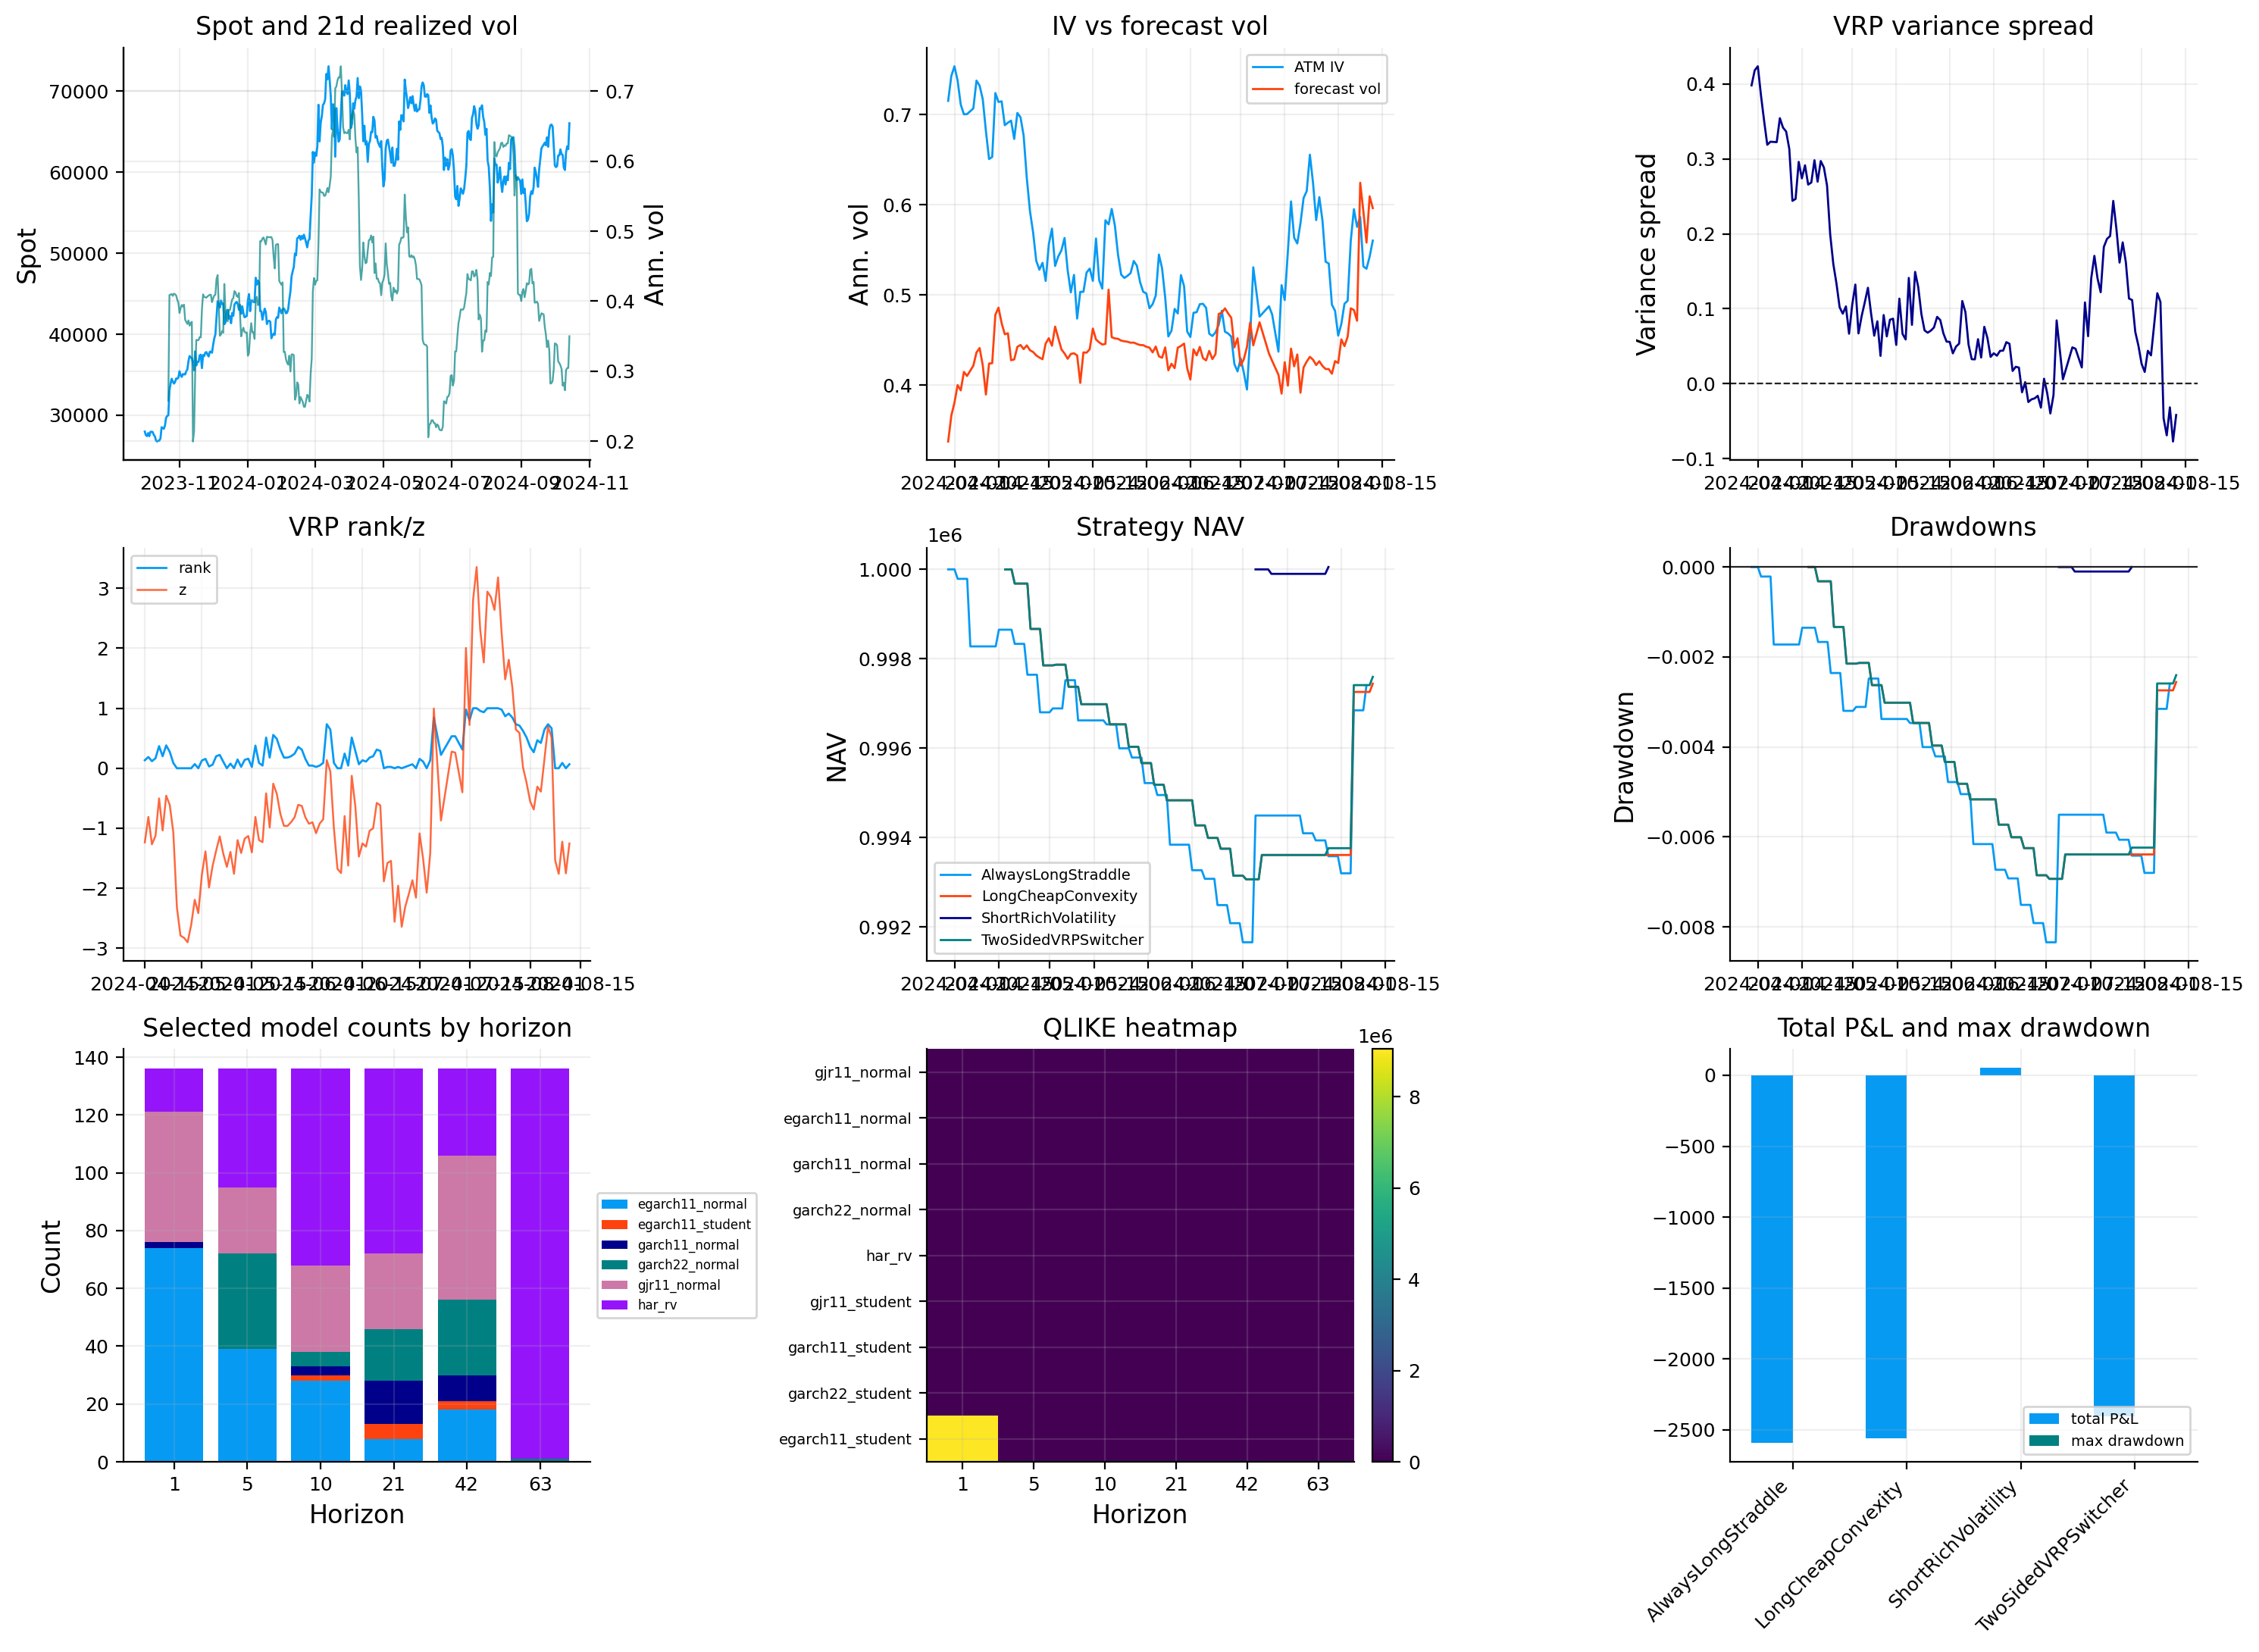

In [75]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

HORIZONS = (1, 5, 10, 21, 42, 63)
ANNUALIZATION = 252
EPS = 1e-12
warnings.filterwarnings("ignore", category=RuntimeWarning, module=r"arch\.univariate\..*")
data_dir = project_root / "data"
btc_option_path = data_dir / "btc_deribit_optiondx_2024_01_09.parquet"
btc_spot_path = data_dir / "btc_usd_yfinance_2023_10_01_2024_10_15.csv"


from quantfinlab.options.quote_cleaning import (
    convert_quotes_to_usd_equivalent,
    detect_option_price_unit,
    ensure_option_mid_quotes,
    normalize_option_quote_schema,
    prepare_underlying_series,
)
from quantfinlab.options.diagnostics import build_atm_iv_panel_from_option_quotes as build_library_atm_iv_panel
from quantfinlab.volatility.forecasting import rolling_arch_forecasts_weekly, score_forecasts_by_model, select_forecast_by_rolling_loss
from quantfinlab.volatility.har import rolling_har_forecasts
from quantfinlab.volatility.vrp import compute_vrp_panel
from quantfinlab.backtest.overlays import backtest_straddle_overlay, summarize_overlay_trades
from quantfinlab.plotting.volatility import plot_volatility_transfer_grid

btc_options_raw = pd.read_parquet(btc_option_path)
btc_spot_raw = pd.read_csv(btc_spot_path)
btc_spot = prepare_underlying_series(btc_spot_raw, name="btc_spot")
btc_returns = np.log(btc_spot / btc_spot.shift(1)).replace([np.inf, -np.inf], np.nan).dropna()
btc_signal_start = btc_returns.index.min() + pd.Timedelta(days=120)
btc_options_norm = normalize_option_quote_schema(btc_options_raw, underlying_default="BTC")
btc_options_norm = ensure_option_mid_quotes(btc_options_norm)
btc_unit_before = detect_option_price_unit(btc_options_norm)
btc_options_usd = convert_quotes_to_usd_equivalent(btc_options_norm, unit="auto")
btc_unit_after = detect_option_price_unit(btc_options_usd)
display(pd.DataFrame([
    {"metric": "BTC option price unit before conversion", "value": btc_unit_before},
    {"metric": "BTC option price unit after conversion", "value": btc_unit_after},
    {"metric": "median raw option mid", "value": float(pd.to_numeric(btc_options_norm["mid"], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna().median())},
    {"metric": "median USD-equivalent option mid", "value": float(pd.to_numeric(btc_options_usd["mid"], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna().median())},
    {"metric": "median BTC spot used for conversion", "value": float(pd.to_numeric(btc_options_usd["spot"], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna().median())},
]))

btc_iv_all = build_library_atm_iv_panel(
    btc_options_usd,
    rates=None,
    constant_rate=0.0,
    min_dte=7,
    max_dte=90,
    moneyness_range=(0.75, 1.25),
    max_relative_spread=0.35,
    closest_atm_pairs=30,
    min_pairs_per_expiry=4,
    underlying_default="BTC",
)
if btc_iv_all.empty:
    raise RuntimeError("BTC ATM IV panel is empty after cleaning.")
btc_iv_daily = (
    btc_iv_all[(btc_iv_all["dte_calendar"] >= 14) & (btc_iv_all["dte_calendar"] <= 45)]
    .assign(dte_score=lambda x: (x["dte_calendar"] - 30.0).abs())
    .sort_values(["date", "dte_score", "quote_quality_score"])
    .groupby("date", as_index=False)
    .head(1)
    .drop(columns=["dte_score"], errors="ignore")
    .reset_index(drop=True)
)
btc_iv_cleaning_report = btc_iv_all.attrs.get("cleaning_report", pd.DataFrame())
display(btc_iv_cleaning_report)
btc_iv_diagnostics = pd.DataFrame([
    {"metric": "raw BTC option rows", "value": int(len(btc_options_raw))},
    {"metric": "BTC option rows after USD conversion", "value": int(len(btc_options_usd))},
    {"metric": "ATM IV rows, all expiries", "value": int(len(btc_iv_all))},
    {"metric": "daily 14-45 DTE ATM rows", "value": int(len(btc_iv_daily))},
    {"metric": "median ATM IV", "value": float(btc_iv_daily["atm_iv_mid"].median())},
    {"metric": "p05 ATM IV", "value": float(btc_iv_daily["atm_iv_mid"].quantile(0.05))},
    {"metric": "p95 ATM IV", "value": float(btc_iv_daily["atm_iv_mid"].quantile(0.95))},
    {"metric": "median DTE calendar", "value": float(btc_iv_daily["dte_calendar"].median())},
    {"metric": "median straddle mid USD", "value": float(btc_iv_daily["straddle_mid"].median())},
])
display(btc_iv_diagnostics)
unit_cols = [c for c in ["call_price_unit_detected", "put_price_unit_detected", "call_valuation_currency", "put_valuation_currency"] if c in btc_iv_daily.columns]
if unit_cols:
    display(btc_iv_daily[unit_cols].astype(str).value_counts().rename("rows").reset_index())
if float(btc_iv_daily["atm_iv_mid"].median()) < 0.05:
    raise RuntimeError(
        "BTC ATM IV is implausibly low after conversion. "
        "Restart the notebook kernel and rerun so the updated quote conversion path is loaded."
    )
raw_price_cols = [c for c in ["date", "expiry", "spot", "strike", "call_mid_raw", "put_mid_raw", "call_mid", "put_mid", "atm_iv_mid"] if c in btc_iv_daily.columns]
btc_price_preview = btc_iv_daily[raw_price_cols].rename(
    columns={
        "call_mid_raw": "call_mid_base",
        "put_mid_raw": "put_mid_base",
        "call_mid": "call_mid_usd",
        "put_mid": "put_mid_usd",
    }
)
display(btc_price_preview.head(10))
btc_train_window = min(180, max(80, len(btc_returns) // 2))
btc_garch = rolling_arch_forecasts_weekly(
    btc_returns,
    horizons=HORIZONS,
    train_window=btc_train_window,
    signal_step=1,
    forecast_start=btc_signal_start,
    annualization=ANNUALIZATION,
    maxiter=350,
)
btc_har = rolling_har_forecasts(
    btc_returns,
    horizons=HORIZONS,
    train_window=btc_train_window,
    refit_every=1,
    annualization=ANNUALIZATION,
    forecast_start=btc_signal_start,
)
btc_fc = pd.concat([btc_garch, btc_har], ignore_index=True).sort_values(["date", "model", "horizon"])
def sanitize_btc_forecast_panel(panel, max_annualized_vol=5.0, min_var=EPS):
    out = panel.copy().replace([np.inf, -np.inf], np.nan)
    numeric_cols = [
        "horizon", "forecast_var_sum", "forecast_var_ann", "forecast_vol_ann",
        "realized_var_sum", "realized_var_ann", "realized_vol_ann",
    ]
    for col in numeric_cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")
    out = out.dropna(subset=["date", "model", "horizon", "forecast_var_sum", "realized_var_sum"]).copy()
    out["horizon"] = out["horizon"].astype(int)
    out["forecast_var_sum_raw"] = out["forecast_var_sum"]
    out["forecast_var_ann_raw"] = out.get("forecast_var_ann", ANNUALIZATION / out["horizon"] * out["forecast_var_sum"])
    max_var_ann = float(max_annualized_vol) ** 2
    cap_sum = max_var_ann * out["horizon"] / float(ANNUALIZATION)
    out["forecast_cap_flag"] = (out["forecast_var_sum"] > cap_sum) | (out["forecast_var_sum"] <= 0)
    out["forecast_var_sum"] = out["forecast_var_sum"].clip(lower=float(min_var), upper=cap_sum)
    out["forecast_var_ann"] = ANNUALIZATION / out["horizon"] * out["forecast_var_sum"]
    out["forecast_vol_ann"] = np.sqrt(out["forecast_var_ann"].clip(lower=0.0))
    out["realized_var_ann"] = ANNUALIZATION / out["horizon"] * out["realized_var_sum"]
    out["realized_vol_ann"] = np.sqrt(out["realized_var_ann"].clip(lower=0.0))
    return out.sort_values(["date", "model", "horizon"]).reset_index(drop=True)
btc_fc = sanitize_btc_forecast_panel(btc_fc, max_annualized_vol=5.0)
btc_forecast_cap_report = (
    btc_fc.groupby("model")["forecast_cap_flag"]
    .agg(n_forecasts="size", n_capped="sum", cap_rate="mean")
    .reset_index()
    .sort_values("cap_rate", ascending=False)
)
display(btc_forecast_cap_report)
btc_forecast_scores = score_forecasts_by_model(btc_fc)
btc_score_pivot = btc_forecast_scores.pivot(index="model", columns="horizon", values="qlike_var")
btc_model_ranks = (
    btc_forecast_scores.assign(qlike_rank=lambda x: x.groupby("horizon")["qlike_var"].rank(method="average"))
    .groupby("model", as_index=False)["qlike_rank"]
    .mean()
    .sort_values("qlike_rank")
    .reset_index(drop=True)
)
display(pd.DataFrame({
    "metric": ["BTC forecast rows", "BTC forecast dates", "BTC models", "BTC train window"],
    "value": [
        int(len(btc_fc)),
        int(btc_fc["date"].nunique()) if not btc_fc.empty else 0,
        int(btc_fc["model"].nunique()) if not btc_fc.empty else 0,
        int(btc_train_window),
    ],
}))
display(btc_model_ranks)
display(btc_forecast_scores[btc_forecast_scores["horizon"].eq(21)].sort_values(["qlike_var", "rmse_vol"]).reset_index(drop=True))
btc_selected = select_forecast_by_rolling_loss(
    btc_fc,
    horizons=HORIZONS,
    lookback=63,
    min_obs=15,
    mode="best",
)
btc_selected_model_counts = btc_selected.groupby(["horizon", "selected_model"]).size().rename("n").reset_index()
display(btc_selected_model_counts.pivot_table(index="selected_model", columns="horizon", values="n", fill_value=0))
btc_vrp_rank_window = 45
btc_vrp_z_window = 45
btc_min_periods = 15
btc_base_cheap_rank = 0.35
btc_base_rich_rank = 0.80
btc_base_holding_days = 3
try:
    btc_vrp = compute_vrp_panel(
        btc_iv_daily,
        btc_selected,
        dte_col="dte_calendar",
        iv_col="atm_iv_mid",
        annualization=ANNUALIZATION,
        z_window=btc_vrp_z_window,
        rank_window=btc_vrp_rank_window,
        min_periods=btc_min_periods,
    )
except TypeError as exc:
    if "rank_window" not in str(exc):
        raise
    btc_vrp = compute_vrp_panel(
        btc_iv_daily,
        btc_selected,
        dte_col="dte_calendar",
        iv_col="atm_iv_mid",
        annualization=ANNUALIZATION,
        z_window=btc_vrp_z_window,
        min_periods=btc_min_periods,
    )
btc_vrp = btc_vrp.sort_values("date").reset_index(drop=True)
vals = btc_vrp["vrp_var"].to_numpy(dtype=float)
ranks = np.full(len(vals), np.nan)
for i in range(len(vals)):
    hist = vals[max(0, i - btc_vrp_rank_window):i]
    hist = hist[np.isfinite(hist)]
    if len(hist) >= btc_min_periods and np.isfinite(vals[i]):
        ranks[i] = np.mean(hist <= vals[i])
btc_vrp["vrp_rank"] = ranks
btc_feature_frame = pd.DataFrame(index=btc_spot.index)
btc_feature_frame["btc_spot"] = btc_spot
btc_feature_frame["ret_1d"] = btc_returns.reindex(btc_feature_frame.index)
btc_feature_frame["ret_5d"] = np.log(btc_feature_frame["btc_spot"] / btc_feature_frame["btc_spot"].shift(5))
btc_feature_frame["trailing_rv_21"] = btc_returns.rolling(21).std() * np.sqrt(ANNUALIZATION)
rv_vals = btc_feature_frame["trailing_rv_21"].to_numpy(dtype=float)
rv_rank = np.full(len(rv_vals), np.nan)
for i, value in enumerate(rv_vals):
    hist = rv_vals[max(0, i - btc_vrp_rank_window):i]
    hist = hist[np.isfinite(hist)]
    if np.isfinite(value) and len(hist) >= btc_min_periods:
        rv_rank[i] = np.mean(hist <= value)
btc_feature_frame["trailing_rv_rank"] = rv_rank
btc_vrp = btc_vrp.merge(
    btc_feature_frame[["ret_1d", "ret_5d", "trailing_rv_21", "trailing_rv_rank"]].reset_index().rename(columns={"index": "date"}),
    on="date",
    how="left",
)
btc_vrp["short_calm_filter"] = (
    btc_vrp["ret_1d"].abs().le(0.05)
    & btc_vrp["ret_5d"].abs().le(0.12)
    & (btc_vrp["trailing_rv_rank"].isna() | btc_vrp["trailing_rv_rank"].le(0.80))
)
display(pd.DataFrame([
    {"setting": "vrp_rank_window", "value": btc_vrp_rank_window},
    {"setting": "vrp_z_window", "value": btc_vrp_z_window},
    {"setting": "min_periods", "value": btc_min_periods},
    {"setting": "base cheap rank", "value": btc_base_cheap_rank},
    {"setting": "base rich rank", "value": btc_base_rich_rank},
    {"setting": "base holding days", "value": btc_base_holding_days},
    {"setting": "short calm abs(ret_1d) <=", "value": 0.05},
    {"setting": "short calm abs(ret_5d) <=", "value": 0.12},
    {"setting": "short calm trailing_rv_rank <=", "value": 0.80},
]))
display(pd.DataFrame([
    {"metric": "BTC VRP rows", "value": int(len(btc_vrp))},
    {"metric": "median IV variance", "value": float((btc_vrp["iv_ann"] ** 2).median()) if "iv_ann" in btc_vrp else np.nan},
    {"metric": "median forecast variance", "value": float(btc_vrp["forecast_var_ann"].median()) if "forecast_var_ann" in btc_vrp else np.nan},
    {"metric": "median VRP variance", "value": float(btc_vrp["vrp_var"].median()) if "vrp_var" in btc_vrp else np.nan},
    {"metric": "non-null VRP rank rows", "value": int(btc_vrp["vrp_rank"].notna().sum()) if "vrp_rank" in btc_vrp else 0},
    {"metric": "short calm filter pass rate", "value": float(btc_vrp["short_calm_filter"].mean())},
]))
display(btc_vrp[["date", "expiry", "dte_calendar", "spot", "strike", "atm_iv_mid", "forecast_vol_ann", "vrp_var", "vrp_z", "vrp_rank", "ret_1d", "ret_5d", "trailing_rv_rank", "short_calm_filter", "selected_model"]].head(12))
def lib_rule(strategy_name, cheap_rank=btc_base_cheap_rank, rich_rank=btc_base_rich_rank):
    def _rule(row):
        rank = row.get("vrp_rank", np.nan)
        cheap = bool(pd.notna(rank) and rank <= cheap_rank)
        rich = bool(pd.notna(rank) and rank >= rich_rank)
        calm_short = bool(row.get("short_calm_filter", False))
        if strategy_name == "AlwaysLongStraddle":
            return {"side": "long"}
        if strategy_name == "LongCheapConvexity":
            return {"side": "long" if cheap else "cash", "skip_reason": "rank_not_cheap"}
        if strategy_name == "ShortRichVolatility":
            if rich and calm_short:
                return {"side": "short"}
            if rich and not calm_short:
                return {"side": "cash", "skip_reason": "short_calm_filter"}
            return {"side": "cash", "skip_reason": "rank_not_rich"}
        if strategy_name == "TwoSidedVRPSwitcher":
            if cheap and not rich:
                return {"side": "long"}
            if rich and not cheap:
                return {"side": "short"} if calm_short else {"side": "cash", "skip_reason": "short_calm_filter"}
            if cheap and rich:
                if rank <= 0.50:
                    return {"side": "long"}
                return {"side": "short"} if calm_short else {"side": "cash", "skip_reason": "short_calm_filter"}
        return {"side": "cash", "skip_reason": "neutral_rank"}
    return _rule
btc_strategy_names = ["AlwaysLongStraddle", "LongCheapConvexity", "ShortRichVolatility", "TwoSidedVRPSwitcher"]
btc_strategy_settings = pd.DataFrame(
    [
        {"strategy": name, "fractional_units": True, "cheap_rank": btc_base_cheap_rank, "rich_rank": btc_base_rich_rank, "holding_days": btc_base_holding_days}
        for name in btc_strategy_names
    ]
)
display(btc_strategy_settings)
def run_btc_overlay_suite(scenario, cheap_rank, rich_rank, holding_days):
    suite = {
        name: backtest_straddle_overlay(
            btc_vrp,
            btc_options_usd,
            btc_spot,
            strategy_name=name,
            signal_rule=lib_rule(name, cheap_rank=cheap_rank, rich_rank=rich_rank),
            initial_nav=1_000_000,
            contract_multiplier=1.0,
            holding_days=int(holding_days),
            allow_overlap=False,
            fractional_units=True,
            long_premium_budget_frac=0.005,
            short_margin_budget_frac=0.02,
            max_short_notional_frac=1.0,
        )
        for name in btc_strategy_names
    }
    summary = summarize_overlay_trades(suite, initial_nav=1_000_000)
    summary["scenario"] = scenario
    summary["cheap_rank"] = cheap_rank
    summary["rich_rank"] = rich_rank
    summary["holding_days"] = int(holding_days)
    return suite, summary
btc_backtests, btc_summary = run_btc_overlay_suite(
    "base",
    cheap_rank=btc_base_cheap_rank,
    rich_rank=btc_base_rich_rank,
    holding_days=btc_base_holding_days,
)
btc_sensitivity_specs = [
    {"scenario": "loose", "cheap_rank": 0.40, "rich_rank": 0.70, "holding_days": 3},
    {"scenario": "base", "cheap_rank": 0.35, "rich_rank": 0.80, "holding_days": 3},
    {"scenario": "strict", "cheap_rank": 0.30, "rich_rank": 0.90, "holding_days": 3},
]
btc_sensitivity_rows = []
for spec in btc_sensitivity_specs:
    _, sens_summary = run_btc_overlay_suite(**spec)
    btc_sensitivity_rows.append(sens_summary)
btc_sensitivity_table = pd.concat(btc_sensitivity_rows, ignore_index=True)
display(btc_sensitivity_table[["scenario", "strategy", "cheap_rank", "rich_rank", "holding_days", "total_net_pnl", "return_on_initial_nav", "max_drawdown", "n_trades", "hit_rate", "avg_trade_pnl"]])
btc_holding_sensitivity_rows = []
for hdays in [1, 2, 3, 5]:
    _, hold_summary = run_btc_overlay_suite(
        f"holding_{hdays}d",
        cheap_rank=btc_base_cheap_rank,
        rich_rank=btc_base_rich_rank,
        holding_days=hdays,
    )
    btc_holding_sensitivity_rows.append(hold_summary)
btc_holding_sensitivity = pd.concat(btc_holding_sensitivity_rows, ignore_index=True)
display(btc_holding_sensitivity[["scenario", "strategy", "holding_days", "total_net_pnl", "max_drawdown", "n_trades", "hit_rate", "avg_trade_pnl"]])
display(btc_summary)
btc_trades = pd.concat([x[0] for x in btc_backtests.values()], ignore_index=True)
btc_equity = pd.concat([x[1] for x in btc_backtests.values()], ignore_index=True)
btc_skips = pd.concat([x[2] for x in btc_backtests.values()], ignore_index=True)
if not btc_trades.empty:
    display(btc_trades.groupby(["strategy", "side"]).agg(n=("net_pnl", "size"), total_pnl=("net_pnl", "sum"), avg_pnl=("net_pnl", "mean"), avg_units=("units", "mean")).reset_index())
    display(btc_trades.assign(year=btc_trades["entry_date"].dt.year).pivot_table(index="year", columns="strategy", values="net_pnl", aggfunc="count", fill_value=0))
    display(btc_trades[["strategy", "side", "entry_date", "exit_date", "expiry", "strike", "units", "net_pnl", "vrp_rank", "vrp_z", "selected_model"]].head(20))
if not btc_skips.empty:
    display(btc_skips.groupby(["strategy", "skip_reason"]).size().rename("n").reset_index().sort_values(["strategy", "n"], ascending=[True, False]).head(30))
fig, axes = plot_volatility_transfer_grid(
    spot=btc_spot,
    returns=btc_returns,
    vrp_panel=btc_vrp,
    equity=btc_equity,
    selected_model_counts=btc_selected_model_counts,
    score_pivot=btc_score_pivot,
    summary=btc_summary,
    model_order=btc_model_ranks["model"].tolist() if not btc_model_ranks.empty else None,
    annualization=ANNUALIZATION,
    figsize=(15.0, 11.0),
)
plt.show()